# Imports

In [1]:
import numpy as np
import torch
import torch.nn as nn
from torch.functional import F
import torchvision.transforms as T
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import kagglehub
import polars as pl
from pathlib import Path
from PIL import Image

import math
import os
from typing import Optional, Tuple, Union, List

from tqdm.auto import tqdm

In [2]:
# Download latest version
path = kagglehub.dataset_download("apollo2506/eurosat-dataset")

print("Path to dataset files:", path)
img_path = os.path.join(path, "EuroSAT")

Path to dataset files: /home/mihalko711/.cache/kagglehub/datasets/apollo2506/eurosat-dataset/versions/6


# Создание Dataset класса

In [3]:
class EuroSATDataset(Dataset):
    def __init__(self, csv_path, image_root, transform=None, filt_class=None, return_label=False):
        self.df = pl.read_csv(csv_path).drop(pl.read_csv(csv_path).columns[0])
        self.image_root = Path(image_root)
        self.transform = transform  # ← внешний трансформ
        self.return_label = return_label

        if filt_class is not None:
            self.df = self.df.filter(pl.col("Label") == filt_class)
            
    def __len__(self):
        return self.df.height

    def __getitem__(self, idx):
        row = self.df.row(idx, named=True)

        img_path = self.image_root / row["Filename"]
        image = Image.open(img_path).convert("RGB")
        
        if self.transform:
            image = self.transform(image)  # ← применяем внешний трансформ

        if self.return_label:
            return image, row["Label"], row["ClassName"]

        return image

# UNet(non conditional)

## Model class

In [3]:
class Swish(nn.Module):
    def forward(self, x):
        return x * torch.sigmoid(x)


class TimeEmbedding(nn.Module):
    """
    ### Embeddings for $t$
    """

    def __init__(self, n_channels: int):
        """
        * `n_channels` is the number of dimensions in the embedding
        """
        super().__init__()
        self.n_channels = n_channels
        # First linear layer
        self.lin1 = nn.Linear(self.n_channels // 4, self.n_channels)
        # Activation
        self.act = Swish()
        # Second linear layer
        self.lin2 = nn.Linear(self.n_channels, self.n_channels)

    def forward(self, t: torch.Tensor):
        # Create sinusoidal position embeddings
        half_dim = self.n_channels // 8
        emb = math.log(10_000) / (half_dim - 1)
        emb = torch.exp(torch.arange(half_dim, device=t.device) * -emb)
        emb = t[:, None] * emb[None, :]
        emb = torch.cat((emb.sin(), emb.cos()), dim=1)

        # Transform with the MLP
        emb = self.act(self.lin1(emb))
        emb = self.lin2(emb)

        #
        return emb


class ResidualBlock(nn.Module):
    """
    ### Residual block

    A residual block has two convolution layers with group normalization.
    Each resolution is processed with two residual blocks.
    """

    def __init__(self, in_channels: int, out_channels: int, time_channels: int,
                 n_groups: int = 16, dropout: float = 0.1):
        """
        * `in_channels` is the number of input channels
        * `out_channels` is the number of input channels
        * `time_channels` is the number channels in the time step ($t$) embeddings
        * `n_groups` is the number of groups for [group normalization](../../normalization/group_norm/index.html)
        * `dropout` is the dropout rate
        """
        super().__init__()
        # Group normalization and the first convolution layer
        self.norm1 = nn.GroupNorm(n_groups, in_channels)
        self.act1 = Swish()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=(3, 3), padding=(1, 1))

        # Group normalization and the second convolution layer
        self.norm2 = nn.GroupNorm(n_groups, out_channels)
        self.act2 = Swish()
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=(3, 3), padding=(1, 1))

        # If the number of input channels is not equal to the number of output channels we have to
        # project the shortcut connection
        if in_channels != out_channels:
            self.shortcut = nn.Conv2d(in_channels, out_channels, kernel_size=(1, 1))
        else:
            self.shortcut = nn.Identity()

        # Linear layer for time embeddings
        self.time_emb = nn.Linear(time_channels, out_channels)
        self.time_act = Swish()

        self.dropout = nn.Dropout(dropout)

    def forward(self, x: torch.Tensor, t: torch.Tensor):
        """
        * `x` has shape `[batch_size, in_channels, height, width]`
        * `t` has shape `[batch_size, time_channels]`
        """
        # First convolution layer
        h = self.conv1(self.act1(self.norm1(x)))
        # Add time embeddings
        h += self.time_emb(self.time_act(t))[:, :, None, None]
        # Second convolution layer
        h = self.conv2(self.dropout(self.act2(self.norm2(h))))

        # Add the shortcut connection and return
        return h + self.shortcut(x)


class AttentionBlock(nn.Module):
    """
    ### Attention block

    This is similar to [transformer multi-head attention](../../transformers/mha.html).
    """

    def __init__(self, n_channels: int, n_heads: int = 1, d_k: int = None, n_groups: int = 16):
        """
        * `n_channels` is the number of channels in the input
        * `n_heads` is the number of heads in multi-head attention
        * `d_k` is the number of dimensions in each head
        * `n_groups` is the number of groups for [group normalization](../../normalization/group_norm/index.html)
        """
        super().__init__()

        # Default `d_k`
        if d_k is None:
            d_k = n_channels
        # Normalization layer
        self.norm = nn.GroupNorm(n_groups, n_channels)
        # Projections for query, key and values
        self.projection = nn.Linear(n_channels, n_heads * d_k * 3)
        # Linear layer for final transformation
        self.output = nn.Linear(n_heads * d_k, n_channels)
        # Scale for dot-product attention
        self.scale = d_k ** -0.5
        #
        self.n_heads = n_heads
        self.d_k = d_k

    def forward(self, x: torch.Tensor, t: Optional[torch.Tensor] = None):
        """
        * `x` has shape `[batch_size, in_channels, height, width]`
        * `t` has shape `[batch_size, time_channels]`
        """
        # `t` is not used, but it's kept in the arguments because for the attention layer function signature
        # to match with `ResidualBlock`.
        _ = t
        # Get shape
        batch_size, n_channels, height, width = x.shape
        # Change `x` to shape `[batch_size, seq, n_channels]`
        x = x.view(batch_size, n_channels, -1).permute(0, 2, 1)
        # Get query, key, and values (concatenated) and shape it to `[batch_size, seq, n_heads, 3 * d_k]`
        qkv = self.projection(x).view(batch_size, -1, self.n_heads, 3 * self.d_k)
        # Split query, key, and values. Each of them will have shape `[batch_size, seq, n_heads, d_k]`
        q, k, v = torch.chunk(qkv, 3, dim=-1)
        # Calculate scaled dot-product $\frac{Q K^\top}{\sqrt{d_k}}$
        attn = torch.einsum('bihd,bjhd->bijh', q, k) * self.scale
        # Softmax along the sequence dimension $\underset{seq}{softmax}\Bigg(\frac{Q K^\top}{\sqrt{d_k}}\Bigg)$
        attn = attn.softmax(dim=2)
        # Multiply by values
        res = torch.einsum('bijh,bjhd->bihd', attn, v)
        # Reshape to `[batch_size, seq, n_heads * d_k]`
        res = res.view(batch_size, -1, self.n_heads * self.d_k)
        # Transform to `[batch_size, seq, n_channels]`
        res = self.output(res)

        # Add skip connection
        res += x

        # Change to shape `[batch_size, in_channels, height, width]`
        res = res.permute(0, 2, 1).view(batch_size, n_channels, height, width)

        #
        return res


class DownBlock(nn.Module):
    """
    ### Down block

    This combines `ResidualBlock` and `AttentionBlock`. These are used in the first half of U-Net at each resolution.
    """

    def __init__(self, in_channels: int, out_channels: int, time_channels: int, has_attn: bool):
        super().__init__()
        self.res = ResidualBlock(in_channels, out_channels, time_channels)
        if has_attn:
            self.attn = AttentionBlock(out_channels)
        else:
            self.attn = nn.Identity()

    def forward(self, x: torch.Tensor, t: torch.Tensor):
        x = self.res(x, t)
        x = self.attn(x)
        return x


class UpBlock(nn.Module):
    """
    ### Up block

    This combines `ResidualBlock` and `AttentionBlock`. These are used in the second half of U-Net at each resolution.
    """

    def __init__(self, in_channels: int, out_channels: int, time_channels: int, has_attn: bool):
        super().__init__()
        # The input has `in_channels + out_channels` because we concatenate the output of the same resolution
        # from the first half of the U-Net
        self.res = ResidualBlock(in_channels + out_channels, out_channels, time_channels)
        if has_attn:
            self.attn = AttentionBlock(out_channels)
        else:
            self.attn = nn.Identity()

    def forward(self, x: torch.Tensor, t: torch.Tensor):
        x = self.res(x, t)
        x = self.attn(x)
        return x


class MiddleBlock(nn.Module):
    """
    ### Middle block

    It combines a `ResidualBlock`, `AttentionBlock`, followed by another `ResidualBlock`.
    This block is applied at the lowest resolution of the U-Net.
    """

    def __init__(self, n_channels: int, time_channels: int):
        super().__init__()
        self.res1 = ResidualBlock(n_channels, n_channels, time_channels)
        self.attn = AttentionBlock(n_channels)
        self.res2 = ResidualBlock(n_channels, n_channels, time_channels)

    def forward(self, x: torch.Tensor, t: torch.Tensor):
        x = self.res1(x, t)
        x = self.attn(x)
        x = self.res2(x, t)
        return x


class Upsample(nn.Module):
    """
    ### Scale up the feature map by $2 \times$
    """

    def __init__(self, n_channels):
        super().__init__()
        self.upsample = nn.Sequential(
            nn.Upsample(scale_factor=2, mode='nearest'), # или 'bilinear'
            nn.Conv2d(n_channels, n_channels, kernel_size=3, padding=1)
        )

    def forward(self, x: torch.Tensor, t: torch.Tensor):
        # `t` is not used, but it's kept in the arguments because for the attention layer function signature
        # to match with `ResidualBlock`.
        _ = t
        return self.upsample(x)


class Downsample(nn.Module):
    """
    ### Scale down the feature map by $\frac{1}{2} \times$
    """

    def __init__(self, n_channels):
        super().__init__()
        self.conv = nn.Conv2d(n_channels, n_channels, (3, 3), (2, 2), (1, 1))

    def forward(self, x: torch.Tensor, t: torch.Tensor):
        # `t` is not used, but it's kept in the arguments because for the attention layer function signature
        # to match with `ResidualBlock`.
        _ = t
        return self.conv(x)


class UNet(nn.Module):
    """
    ## U-Net
    """

    def __init__(self, image_channels: int = 3, n_channels: int = 64,
                 ch_mults: Union[Tuple[int, ...], List[int]] = (1, 2, 2, 4),
                 is_attn: Union[Tuple[bool, ...], List[bool]] = (False, False, True, True),
                 n_blocks: int = 2):
        """
        * `image_channels` is the number of channels in the image. $3$ for RGB.
        * `n_channels` is number of channels in the initial feature map that we transform the image into
        * `ch_mults` is the list of channel numbers at each resolution. The number of channels is `ch_mults[i] * n_channels`
        * `is_attn` is a list of booleans that indicate whether to use attention at each resolution
        * `n_blocks` is the number of `UpDownBlocks` at each resolution
        """
        super().__init__()

        # Number of resolutions
        n_resolutions = len(ch_mults)

        # Project image into feature map
        self.image_proj = nn.Conv2d(image_channels, n_channels, kernel_size=(3, 3), padding=(1, 1))

        # Time embedding layer. Time embedding has `n_channels * 4` channels
        self.time_emb = TimeEmbedding(n_channels * 4)

        # #### First half of U-Net - decreasing resolution
        down = []
        # Number of channels
        out_channels = in_channels = n_channels
        # For each resolution
        for i in range(n_resolutions):
            # Number of output channels at this resolution
            out_channels = in_channels * ch_mults[i]
            # Add `n_blocks`
            for _ in range(n_blocks):
                down.append(DownBlock(in_channels, out_channels, n_channels * 4, is_attn[i]))
                in_channels = out_channels
            # Down sample at all resolutions except the last
            if i < n_resolutions - 1:
                down.append(Downsample(in_channels))

        # Combine the set of modules
        self.down = nn.ModuleList(down)

        # Middle block
        self.middle = MiddleBlock(out_channels, n_channels * 4, )

        # #### Second half of U-Net - increasing resolution
        up = []
        # Number of channels
        in_channels = out_channels
        # For each resolution
        for i in reversed(range(n_resolutions)):
            # `n_blocks` at the same resolution
            out_channels = in_channels
            for _ in range(n_blocks):
                up.append(UpBlock(in_channels, out_channels, n_channels * 4, is_attn[i]))
            # Final block to reduce the number of channels
            out_channels = in_channels // ch_mults[i]
            up.append(UpBlock(in_channels, out_channels, n_channels * 4, is_attn[i]))
            in_channels = out_channels
            # Up sample at all resolutions except last
            if i > 0:
                up.append(Upsample(in_channels))

        # Combine the set of modules
        self.up = nn.ModuleList(up)

        # Final normalization and convolution layer
        self.norm = nn.GroupNorm(8, n_channels)
        self.act = Swish()
        self.final = nn.Conv2d(in_channels, image_channels, kernel_size=(3, 3), padding=(1, 1))

    def forward(self, x: torch.Tensor, t: torch.Tensor):
        """
        * `x` has shape `[batch_size, in_channels, height, width]`
        * `t` has shape `[batch_size]`
        """

        # Get time-step embeddings
        t = self.time_emb(t)

        # Get image projection
        x = self.image_proj(x)

        # `h` will store outputs at each resolution for skip connection
        h = [x]
        # First half of U-Net
        for m in self.down:
            x = m(x, t)
            h.append(x)

        # Middle (bottom)
        x = self.middle(x, t)

        # Second half of U-Net
        for m in self.up:
            if isinstance(m, Upsample):
                x = m(x, t)
            else:
                # Get the skip connection from first half of U-Net and concatenate
                s = h.pop()
                x = torch.cat((x, s), dim=1)
                #
                x = m(x, t)

        # Final normalization and convolution
        return self.final(self.act(self.norm(x)))

## schedules

In [4]:
def cosine_beta_schedule(timesteps, s=0.008):
    """
    cosine schedule as proposed in https://arxiv.org/abs/2102.09672
    """
    steps = timesteps + 1
    x = torch.linspace(0, timesteps, steps)
    alphas_cumprod = torch.cos(((x / timesteps) + s) / (1 + s) * torch.pi * 0.5) ** 2
    alphas_cumprod = alphas_cumprod / alphas_cumprod[0]
    betas = 1 - (alphas_cumprod[1:] / alphas_cumprod[:-1])
    return torch.clip(betas, 0.0001, 0.9999)

def linear_beta_schedule(timesteps):
    beta_start = 0.0001
    beta_end = 0.02
    return torch.linspace(beta_start, beta_end, timesteps)

def quadratic_beta_schedule(timesteps):
    beta_start = 0.0001
    beta_end = 0.02
    return torch.linspace(beta_start**0.5, beta_end**0.5, timesteps) ** 2

def sigmoid_beta_schedule(timesteps):
    beta_start = 0.0001
    beta_end = 0.02
    betas = torch.linspace(-6, 6, timesteps)
    return torch.sigmoid(betas) * (beta_end - beta_start) + beta_start


[Text(0.5, 1.0, 'sigmoid')]

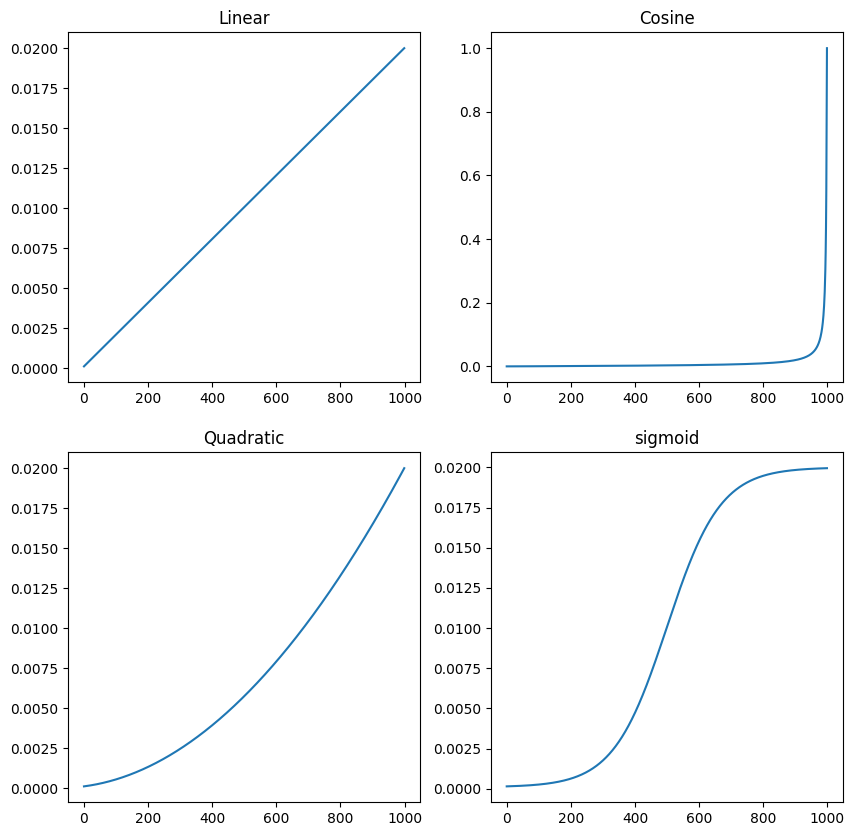

In [5]:
timesteps = 1000

fig, ax = plt.subplots(2, 2, figsize=(10, 10))


ax[0][0].plot(linear_beta_schedule(timesteps))
ax[0][1].plot(cosine_beta_schedule(timesteps))
ax[1][0].plot(quadratic_beta_schedule(timesteps))
ax[1][1].plot(sigmoid_beta_schedule(timesteps))

ax[0][0].set(title=f"Linear")
ax[0][1].set(title=f"Cosine")
ax[1][0].set(title=f"Quadratic")
ax[1][1].set(title=f"sigmoid")

In [7]:
train_transform = T.Compose([
    T.RandomHorizontalFlip(p=0.5),
    T.RandomVerticalFlip(p=0.5),
    T.RandomChoice([
        T.Lambda(lambda x: x),                          # 0°
        T.Lambda(lambda x: x.rotate(90, expand=False)),   # 90°
        T.Lambda(lambda x: x.rotate(180, expand=False)),  # 180°
        T.Lambda(lambda x: x.rotate(270, expand=False)),  # 270°
    ]),
    T.ColorJitter(brightness=0.05, contrast=0.05),
    T.RandomApply([T.GaussianBlur(3, (0.1, 0.3))], p=0.05),
    T.Resize((64, 64)),  # Для надёжности (изображения EuroSAT уже 64×64)
    T.ToTensor(),
    T.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])  # → [-1, 1]
])

val_transform = T.Compose([
    T.Resize((64, 64)),
    T.ToTensor(),
    T.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])
# Создание датасетов
train_dataset = EuroSATDataset(
    csv_path=os.path.join(img_path, "train.csv"),
    image_root=img_path,
    transform=train_transform,
    return_label=True
)

val_dataset = EuroSATDataset(
    csv_path=os.path.join(img_path, "validation.csv"),
    image_root=img_path,
    transform=val_transform,
    return_label=True
)

print(f"Train dataset size: {len(train_dataset)}")
print(f"Validation dataset size: {len(val_dataset)}")

Train dataset size: 18900
Validation dataset size: 5400


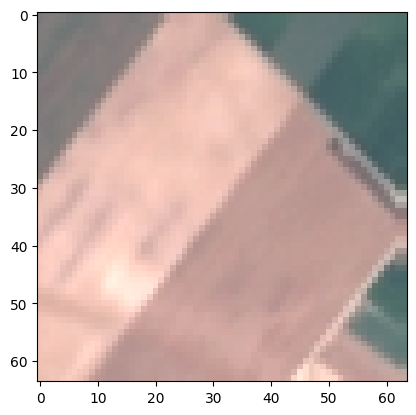

In [8]:
plt.imshow((train_dataset[0][0].permute(1, 2, 0) + 1) / 2)

## Class for DDPM

In [9]:
class DDPM:
    def __init__(self, beta_schedule, model=None, device='cpu'):
        self.beta_schedule = beta_schedule
        self.alpha_schedule = 1 - beta_schedule
        self.alpha_hat_schedule = torch.cumprod(self.alpha_schedule, dim=0)
        self.model = model
        self.device = device

        self.beta_schedule = self.beta_schedule.to(device)
        self.alpha_schedule = self.alpha_schedule.to(device)
        self.alpha_hat_schedule = self.alpha_hat_schedule.to(device)
        self.timesteps = len(self.beta_schedule)

    def forward_process(self, x_0, t):
        """
        x_0: [B, C, H, W] - батч чистых картинок
        t:   [B]           - батч случайных таймстепов
        """
        # 1. Генерируем случайный шум для всего батча
        eps = torch.randn_like(x_0)

        # 2. Выбираем нужные альфа-хэт для каждого элемента в батче
        # alpha_t будет иметь форму (B,)
        alpha_t = self.alpha_hat_schedule[t]

        # 3. Растягиваем (B,) до (B, 1, 1, 1), чтобы сработало умножение (broadcasting)
        # Это делается через .view(-1, 1, 1, 1) или [:, None, None, None]
        alpha_t = alpha_t.view(-1, 1, 1, 1)

        # 4. Формула диффузии
        noisy_x = torch.sqrt(alpha_t) * x_0 + torch.sqrt(1 - alpha_t) * eps
        
        return noisy_x, eps

    def generate_timesteps(self, x_0):
        return torch.randint(self.timesteps, (x_0.shape[0], ))


Text(0.5, 0.98, 'Image noising on timestep 300')

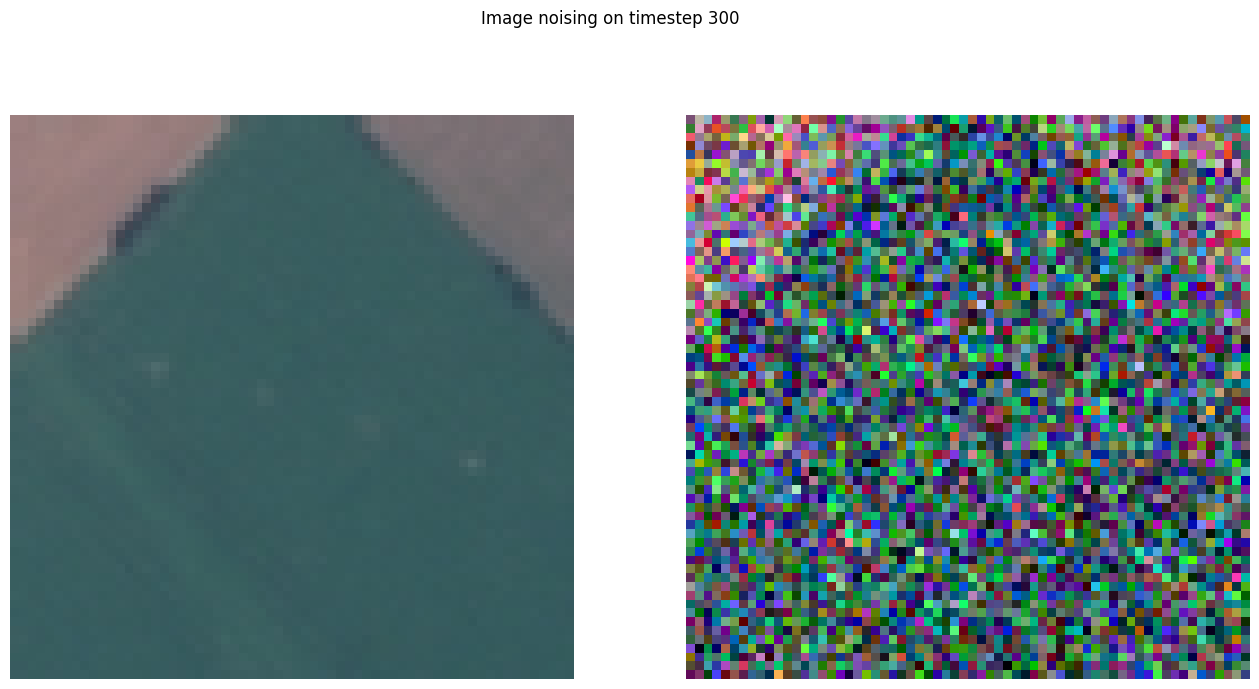

In [10]:
timesteps = 1000
beta_schedule = cosine_beta_schedule(timesteps)

ddpm = DDPM(beta_schedule)

imag = train_dataset[torch.randint(len(train_dataset), (1,))][0].permute(1, 2, 0)

# timestep = torch.randint(timesteps, (1, ))
timestep = torch.tensor([300])
noised_imag, _ = ddpm.forward_process(imag, timestep)

fig, ax = plt.subplots(1, 2, figsize=(16, 8))

ax[0].axis('off')
ax[0].imshow((imag + 1) / 2)

ax[1].axis('off')
ax[1].imshow(torch.clamp((noised_imag[0] + 1) / 2, 0, 1))

fig.suptitle(f"Image noising on timestep {timestep[0]}")

## Train loop

In [11]:
def train_ddpm(ddpm, train_dataset, val_dataset, optimizer, device, info_interval=5,
                  epochs=50, batch_size=128):
    train_loader = DataLoader(train_dataset, batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size)
    criterion = nn.MSELoss() 
    
    for epoch in range(epochs):
        model.train()
        
        pbar = tqdm(train_loader, desc=f"Epoch {epoch}/{epochs} [Train]", leave=False)

        total_train_loss = 0
        for data, labels, _ in pbar:
            data, labels = data.to(device), labels.to(device)
            optimizer.zero_grad()
            
            t = ddpm.generate_timesteps(data).to(device)
            noisy_data, noise = ddpm.forward_process(data, t)

            noise_pred = ddpm.model(noisy_data.to(device), t.to(device))

            loss = criterion(noise_pred, noise)

            total_train_loss += loss.item()
            
            loss.backward()
            optimizer.step()
            
            pbar.set_postfix({
                'Loss': f"{loss.item():.5f}"
            })
            
        # --- ФАЗА ВАЛИДАЦИИ ---
        model.eval()

        total_val_loss = 0
        with torch.no_grad():
            for data, labels, _ in tqdm(val_loader, desc='Validation', leave=False):
                data, labels = data.to(device), labels.to(device)

                t = ddpm.generate_timesteps(data).to(device)
                noisy_data, noise = ddpm.forward_process(data, t)
    
                noise_pred = ddpm.model(noisy_data.to(device), t.to(device))
    
                loss = criterion(noise_pred, noise)

                total_val_loss += loss.item()
                

        if epoch % info_interval == 0:
            tqdm.write(f"Train loss: {total_train_loss / len(train_loader)} | Val loss: {total_val_loss / len(val_loader)}")
    # return history

In [12]:
def print_gpu_memory():
    if torch.cuda.is_available():
        # Текущая выделенная память под тензоры
        allocated = torch.cuda.memory_allocated() / 1024**2
        # Память, зарезервированная кэшем PyTorch
        reserved = torch.cuda.memory_reserved() / 1024**2
        # Максимальная память, которую PyTorch занимал за всё время работы скрипта
        max_allocated = torch.cuda.max_memory_allocated() / 1024**2
        
        print(f"--- GPU Memory Report ---")
        print(f"Занято тензорами: {allocated:.2f} MB")
        print(f"Зарезервировано:  {reserved:.2f} MB")
        print(f"Пик за всё время: {max_allocated:.2f} MB")
        print(f"-------------------------")

In [13]:


# Параметры обучения
batch_size = 48
epochs = 4
learning_rate = 1e-4
info_interval = 1

# Устройство
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")



# Создание модели
timesteps = 500
beta_schedule = linear_beta_schedule(timesteps)
model = UNet(n_channels = 16).to(device)
ddpm = DDPM(beta_schedule, model, device)


# Создание оптимизатора
optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate)

print_gpu_memory()


Using device: cuda
--- GPU Memory Report ---
Занято тензорами: 40.27 MB
Зарезервировано:  52.00 MB
Пик за всё время: 40.27 MB
-------------------------


In [50]:
learning_rate = 1e-5
epochs = 4

optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate)

In [51]:
train_ddpm(ddpm, train_dataset, val_dataset, optimizer, device, batch_size=batch_size, epochs=epochs, info_interval=info_interval)

Epoch 0/4 [Train]:   0%|          | 0/394 [00:00<?, ?it/s]

Validation:   0%|          | 0/113 [00:00<?, ?it/s]

Train loss: 0.024745670609355806 | Val loss: 0.02273353283186402


Epoch 1/4 [Train]:   0%|          | 0/394 [00:00<?, ?it/s]

Validation:   0%|          | 0/113 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/113 [00:00<?, ?it/s]

Train loss: 0.024002506402392074 | Val loss: 0.02231803978999368


Epoch 3/4 [Train]:   0%|          | 0/394 [00:00<?, ?it/s]

Validation:   0%|          | 0/113 [00:00<?, ?it/s]

Train loss: 0.02382058759224672 | Val loss: 0.021525648546166124


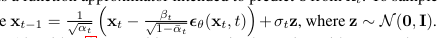

In [58]:
imag_shape = train_dataset[0][0].shape 
noise = torch.randn((1, *imag_shape), device=device)
curr_imag = noise

# 3. Sampling Loop
with torch.no_grad():
    for timestep in torch.arange(ddpm.timesteps - 1, -1, -1):
        t = torch.full((1,), timestep, dtype=torch.long, device=device)
        
        # 1. Predict noise
        eps = ddpm.model(curr_imag, t)
        
        # 2. Get schedule values for this timestep
        # Ensure these are tensors on the correct device
        alpha_t = ddpm.alpha_schedule[t]
        alpha_hat_t = ddpm.alpha_hat_schedule[t]
        beta_t = ddpm.beta_schedule[t]
        
        # 3. Calculate Mean (mu_theta)
        # Formula: 1/sqrt(alpha) * (x_t - (beta / sqrt(1 - alpha_hat)) * eps)
        coef1 = 1.0 / torch.sqrt(alpha_t)
        coef2 = beta_t / torch.sqrt(1.0 - alpha_hat_t)
        
        mean = coef1 * (curr_imag - coef2 * eps)
        
        # 4. Calculate Variance / Add Noise
        # If t > 0, add noise. If t == 0, sigma = 0 (no noise)
        if timestep > 0:
            noise = torch.randn_like(curr_imag)
            variance = torch.sqrt(beta_t) * noise
            curr_imag = mean + variance
        else:
            curr_imag = mean

        # Optional: Print progress
        print(f"Timestep: {timestep}, EPS Shape: {eps.shape}")

# curr_imag now contains the generated image at t=0
generated_image = torch.clamp(curr_imag.squeeze(0).cpu(), -1, 1)

Timestep: 499, EPS Shape: torch.Size([1, 3, 64, 64])
Timestep: 498, EPS Shape: torch.Size([1, 3, 64, 64])
Timestep: 497, EPS Shape: torch.Size([1, 3, 64, 64])
Timestep: 496, EPS Shape: torch.Size([1, 3, 64, 64])
Timestep: 495, EPS Shape: torch.Size([1, 3, 64, 64])
Timestep: 494, EPS Shape: torch.Size([1, 3, 64, 64])
Timestep: 493, EPS Shape: torch.Size([1, 3, 64, 64])
Timestep: 492, EPS Shape: torch.Size([1, 3, 64, 64])
Timestep: 491, EPS Shape: torch.Size([1, 3, 64, 64])
Timestep: 490, EPS Shape: torch.Size([1, 3, 64, 64])
Timestep: 489, EPS Shape: torch.Size([1, 3, 64, 64])
Timestep: 488, EPS Shape: torch.Size([1, 3, 64, 64])
Timestep: 487, EPS Shape: torch.Size([1, 3, 64, 64])
Timestep: 486, EPS Shape: torch.Size([1, 3, 64, 64])
Timestep: 485, EPS Shape: torch.Size([1, 3, 64, 64])
Timestep: 484, EPS Shape: torch.Size([1, 3, 64, 64])
Timestep: 483, EPS Shape: torch.Size([1, 3, 64, 64])
Timestep: 482, EPS Shape: torch.Size([1, 3, 64, 64])
Timestep: 481, EPS Shape: torch.Size([1, 3, 64

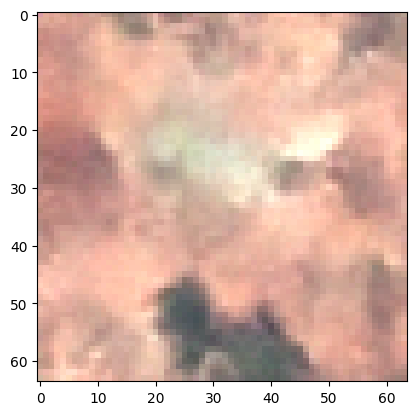

In [59]:
plt.imshow((generated_image.permute(1, 2, 0) + 1) / 2)

# UNet(conditional)

## Model

In [4]:
import math
from typing import Union, Tuple, List, Optional

import torch
from torch import nn


class TimeEmbedding(nn.Module):
    """
    ### Embeddings for $t$
    """

    def __init__(self, n_channels: int):
        """
        * `n_channels` is the number of dimensions in the embedding
        """
        super().__init__()
        self.n_channels = n_channels
        # First linear layer
        self.lin1 = nn.Linear(self.n_channels // 4, self.n_channels)
        # Activation
        self.act = nn.SiLU()
        # Second linear layer
        self.lin2 = nn.Linear(self.n_channels, self.n_channels)

    def forward(self, t: torch.Tensor):
        # Create sinusoidal position embeddings
        half_dim = self.n_channels // 8
        emb = math.log(10_000) / (half_dim - 1)
        emb = torch.exp(torch.arange(half_dim, device=t.device) * -emb)
        emb = t[:, None] * emb[None, :]
        emb = torch.cat((emb.sin(), emb.cos()), dim=1)

        # Transform with the MLP
        emb = self.act(self.lin1(emb))
        emb = self.lin2(emb)

        #
        return emb


class ResidualBlock(nn.Module):
    """
    ### Residual block

    A residual block has two convolution layers with group normalization.
    Each resolution is processed with two residual blocks.
    """

    def __init__(self, in_channels: int, out_channels: int, cond_channels: int,
                 n_groups: int = 16, dropout: float = 0.1, act: callable = nn.SiLU()):
        """
        * `in_channels` is the number of input channels
        * `out_channels` is the number of input channels
        * `cond_channels` is the number channels in the combined (time + label) embeddings
        * `n_groups` is the number of groups for [group normalization](../../normalization/group_norm/index.html)
        * `dropout` is the dropout rate
        """
        super().__init__()
        # Group normalization and the first convolution layer
        self.norm1 = nn.GroupNorm(n_groups, in_channels)
        self.act1 = act
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=(3, 3), padding=(1, 1))

        # Group normalization and the second convolution layer
        self.norm2 = nn.GroupNorm(n_groups, out_channels)
        self.act2 = act
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=(3, 3), padding=(1, 1))

        # If the number of input channels is not equal to the number of output channels we have to
        # project the shortcut connection
        if in_channels != out_channels:
            self.shortcut = nn.Conv2d(in_channels, out_channels, kernel_size=(1, 1))
        else:
            self.shortcut = nn.Identity()

        # Linear layer for condition embeddings (AdaGN)
        self.cond_proj = nn.Linear(cond_channels, 2 * out_channels)

        self.dropout = nn.Dropout(dropout)
        
    def forward(self, x: torch.Tensor, t: torch.Tensor):
        """
        * `x` has shape `[batch_size, in_channels, height, width]`
        * `t` has shape `[batch_size, cond_channels]` (combined embedding)
        """
        # First convolution layer
        h = self.conv1(self.act1(self.norm1(x)))

        # AdaGN (Scale and Shift)
        cond_params = self.cond_proj(t)[:, :, None, None]
        scale, shift = torch.chunk(cond_params, 2, dim=1)
        
        # Second convolution layer with adaptive norm
        h = self.norm2(h)
        h = h * (1 + scale) + shift
        h = self.conv2(self.dropout(self.act2(h)))

        # Add the shortcut connection and return
        return h + self.shortcut(x)


class AttentionBlock(nn.Module):
    """
    ### Attention block

    This is similar to [transformer multi-head attention](../../transformers/mha.html).
    """

    def __init__(self, n_channels: int, n_heads: int = 1, d_k: int = None, n_groups: int = 16):
        """
        * `n_channels` is the number of channels in the input
        * `n_heads` is the number of heads in multi-head attention
        * `d_k` is the number of dimensions in each head
        * `n_groups` is the number of groups for [group normalization](../../normalization/group_norm/index.html)
        """
        super().__init__()

        # Default `d_k`
        if d_k is None:
            d_k = n_channels
        # Normalization layer
        self.norm = nn.GroupNorm(n_groups, n_channels)
        # Projections for query, key and values
        self.projection = nn.Linear(n_channels, n_heads * d_k * 3)
        # Linear layer for final transformation
        self.output = nn.Linear(n_heads * d_k, n_channels)
        # Scale for dot-product attention
        self.scale = d_k ** -0.5
        #
        self.n_heads = n_heads
        self.d_k = d_k

    def forward(self, x: torch.Tensor, t: Optional[torch.Tensor] = None):
        """
        * `x` has shape `[batch_size, in_channels, height, width]`
        * `t` has shape `[batch_size, cond_channels]`
        """
        # `t` is not used, but it's kept in the arguments because for the attention layer function signature
        # to match with `ResidualBlock`.
        _ = t
        # Get shape
        batch_size, n_channels, height, width = x.shape
        # Change `x` to shape `[batch_size, seq, n_channels]`
        x = x.view(batch_size, n_channels, -1).permute(0, 2, 1)
        # Get query, key, and values (concatenated) and shape it to `[batch_size, seq, n_heads, 3 * d_k]`
        qkv = self.projection(x).view(batch_size, -1, self.n_heads, 3 * self.d_k)
        # Split query, key, and values. Each of them will have shape `[batch_size, seq, n_heads, d_k]`
        q, k, v = torch.chunk(qkv, 3, dim=-1)
        # Calculate scaled dot-product $\frac{Q K^\top}{\sqrt{d_k}}$
        attn = torch.einsum('bihd,bjhd->bijh', q, k) * self.scale
        # Softmax along the sequence dimension $\underset{seq}{softmax}\Bigg(\frac{Q K^\top}{\sqrt{d_k}}\Bigg)$
        attn = attn.softmax(dim=2)
        # Multiply by values
        res = torch.einsum('bijh,bjhd->bihd', attn, v)
        # Reshape to `[batch_size, seq, n_heads * d_k]`
        res = res.view(batch_size, -1, self.n_heads * self.d_k)
        # Transform to `[batch_size, seq, n_channels]`
        res = self.output(res)

        # Add skip connection
        res += x

        # Change to shape `[batch_size, in_channels, height, width]`
        res = res.permute(0, 2, 1).view(batch_size, n_channels, height, width)

        #
        return res


class DownBlock(nn.Module):
    """
    ### Down block

    This combines `ResidualBlock` and `AttentionBlock`. These are used in the first half of U-Net at each resolution.
    """

    def __init__(self, in_channels: int, out_channels: int, cond_channels: int, has_attn: bool):
        super().__init__()
        self.res = ResidualBlock(in_channels, out_channels, cond_channels)
        if has_attn:
            self.attn = AttentionBlock(out_channels)
        else:
            self.attn = nn.Identity()

    def forward(self, x: torch.Tensor, t: torch.Tensor):
        x = self.res(x, t)
        x = self.attn(x)
        return x


class UpBlock(nn.Module):
    """
    ### Up block

    This combines `ResidualBlock` and `AttentionBlock`. These are used in the second half of U-Net at each resolution.
    """

    def __init__(self, in_channels: int, out_channels: int, cond_channels: int, has_attn: bool):
        super().__init__()
        # The input has `in_channels + out_channels` because we concatenate the output of the same resolution
        # from the first half of the U-Net
        self.res = ResidualBlock(in_channels + out_channels, out_channels, cond_channels)
        if has_attn:
            self.attn = AttentionBlock(out_channels)
        else:
            self.attn = nn.Identity()

    def forward(self, x: torch.Tensor, t: torch.Tensor):
        x = self.res(x, t)
        x = self.attn(x)
        return x


class MiddleBlock(nn.Module):
    """
    ### Middle block

    It combines a `ResidualBlock`, `AttentionBlock`, followed by another `ResidualBlock`.
    This block is applied at the lowest resolution of the U-Net.
    """

    def __init__(self, n_channels: int, cond_channels: int):
        super().__init__()
        self.res1 = ResidualBlock(n_channels, n_channels, cond_channels)
        self.attn = AttentionBlock(n_channels)
        self.res2 = ResidualBlock(n_channels, n_channels, cond_channels)

    def forward(self, x: torch.Tensor, t: torch.Tensor):
        x = self.res1(x, t)
        x = self.attn(x)
        x = self.res2(x, t)
        return x


class Upsample(nn.Module):
    """
    ### Scale up the feature map by $2 \times$
    """

    def __init__(self, n_channels):
        super().__init__()
        self.upsample = nn.Sequential(
            nn.Upsample(scale_factor=2, mode='nearest'), # или 'bilinear'
            nn.Conv2d(n_channels, n_channels, kernel_size=3, padding=1)
        )

    def forward(self, x: torch.Tensor, t: torch.Tensor):
        # `t` is not used, but it's kept in the arguments because for the attention layer function signature
        # to match with `ResidualBlock`.
        _ = t
        return self.upsample(x)


class Downsample(nn.Module):
    """
    ### Scale down the feature map by $\frac{1}{2} \times$
    """

    def __init__(self, n_channels):
        super().__init__()
        self.conv = nn.Conv2d(n_channels, n_channels, (3, 3), (2, 2), (1, 1))

    def forward(self, x: torch.Tensor, t: torch.Tensor):
        # `t` is not used, but it's kept in the arguments because for the attention layer function signature
        # to match with `ResidualBlock`.
        _ = t
        return self.conv(x)


class UNet(nn.Module):
    """
    ## U-Net
    """

    def __init__(self, image_channels: int = 3, n_channels: int = 64,
                 ch_mults: Union[Tuple[int, ...], List[int]] = (1, 2, 2, 4),
                 is_attn: Union[Tuple[bool, ...], List[bool]] = (False, False, True, True),
                 n_blocks: int = 2, act: callable = nn.SiLU(),
                 num_classes: Optional[int] = None, label_emb_dim: int = 128):
        """
        * `image_channels` is the number of channels in the image. $3$ for RGB.
        * `n_channels` is number of channels in the initial feature map that we transform the image into
        * `ch_mults` is the list of channel numbers at each resolution. The number of channels is `ch_mults[i] * n_channels`
        * `is_attn` is a list of booleans that indicate whether to use attention at each resolution
        * `n_blocks` is the number of `UpDownBlocks` at each resolution
        """
        super().__init__()

        # Number of resolutions
        n_resolutions = len(ch_mults)

        # Project image into feature map
        self.image_proj = nn.Conv2d(image_channels, n_channels, kernel_size=(3, 3), padding=(1, 1))

        # Time embedding layer. Time embedding has `n_channels * 4` channels
        self.time_emb = TimeEmbedding(n_channels * 4)
        
        # Label embedding and condition mixer
        cond_channels = n_channels * 4
        if num_classes is not None:
            self.label_emb = nn.Embedding(num_classes, label_emb_dim)
            self.cond_mixer = nn.Sequential(
                nn.Linear(n_channels * 4 + label_emb_dim, cond_channels),
                act,
                nn.Linear(cond_channels, cond_channels),
            )
        else:
            self.label_emb = None

        # #### First half of U-Net - decreasing resolution
        down = []
        # Number of channels
        out_channels = in_channels = n_channels
        # For each resolution
        for i in range(n_resolutions):
            # Number of output channels at this resolution
            out_channels = in_channels * ch_mults[i]
            # Add `n_blocks`
            for _ in range(n_blocks):
                down.append(DownBlock(in_channels, out_channels, cond_channels, is_attn[i]))
                in_channels = out_channels
            # Down sample at all resolutions except the last
            if i < n_resolutions - 1:
                down.append(Downsample(in_channels))

        # Combine the set of modules
        self.down = nn.ModuleList(down)

        # Middle block
        self.middle = MiddleBlock(out_channels, cond_channels)

        # #### Second half of U-Net - increasing resolution
        up = []
        # Number of channels
        in_channels = out_channels
        # For each resolution
        for i in reversed(range(n_resolutions)):
            # `n_blocks` at the same resolution
            out_channels = in_channels
            for _ in range(n_blocks):
                up.append(UpBlock(in_channels, out_channels, cond_channels, is_attn[i]))
            # Final block to reduce the number of channels
            out_channels = in_channels // ch_mults[i]
            up.append(UpBlock(in_channels, out_channels, cond_channels, is_attn[i]))
            in_channels = out_channels
            # Up sample at all resolutions except last
            if i > 0:
                up.append(Upsample(in_channels))

        # Combine the set of modules
        self.up = nn.ModuleList(up)

        # Final normalization and convolution layer
        self.norm = nn.GroupNorm(8, n_channels)
        self.act = act
        self.final = nn.Conv2d(in_channels, image_channels, kernel_size=(3, 3), padding=(1, 1))

    def forward(self, x: torch.Tensor, t: torch.Tensor, label: Optional[torch.Tensor] = None):
        """
        * `x` has shape `[batch_size, in_channels, height, width]`
        * `t` has shape `[batch_size]`
        """

        # Get time-step embeddings
        t = self.time_emb(t)
        
        # Combine with label embeddings if available
        if self.label_emb is not None and label is not None:
            l_emb = self.label_emb(label)
            t = self.cond_mixer(torch.cat([t, l_emb], dim=-1))

        # Get image projection
        x = self.image_proj(x)

        # `h` will store outputs at each resolution for skip connection
        h = [x]
        # First half of U-Net
        for m in self.down:
            x = m(x, t)
            h.append(x)

        # Middle (bottom)
        x = self.middle(x, t)

        # Second half of U-Net
        for m in self.up:
            if isinstance(m, Upsample):
                x = m(x, t)
            else:
                # Get the skip connection from first half of U-Net and concatenate
                s = h.pop()
                x = torch.cat((x, s), dim=1)
                #
                x = m(x, t)

        # Final normalization and convolution
        return self.final(self.act(self.norm(x)))

## schedules

In [5]:
def cosine_beta_schedule(timesteps, s=0.008):
    """
    cosine schedule as proposed in https://arxiv.org/abs/2102.09672
    """
    steps = timesteps + 1
    x = torch.linspace(0, timesteps, steps)
    alphas_cumprod = torch.cos(((x / timesteps) + s) / (1 + s) * torch.pi * 0.5) ** 2
    alphas_cumprod = alphas_cumprod / alphas_cumprod[0]
    betas = 1 - (alphas_cumprod[1:] / alphas_cumprod[:-1])
    return torch.clip(betas, 0.0001, 0.9999)

def linear_beta_schedule(timesteps):
    beta_start = 0.0001
    beta_end = 0.02
    return torch.linspace(beta_start, beta_end, timesteps)

def quadratic_beta_schedule(timesteps):
    beta_start = 0.0001
    beta_end = 0.02
    return torch.linspace(beta_start**0.5, beta_end**0.5, timesteps) ** 2

def sigmoid_beta_schedule(timesteps):
    beta_start = 0.0001
    beta_end = 0.02
    betas = torch.linspace(-6, 6, timesteps)
    return torch.sigmoid(betas) * (beta_end - beta_start) + beta_start


[Text(0.5, 1.0, 'sigmoid')]

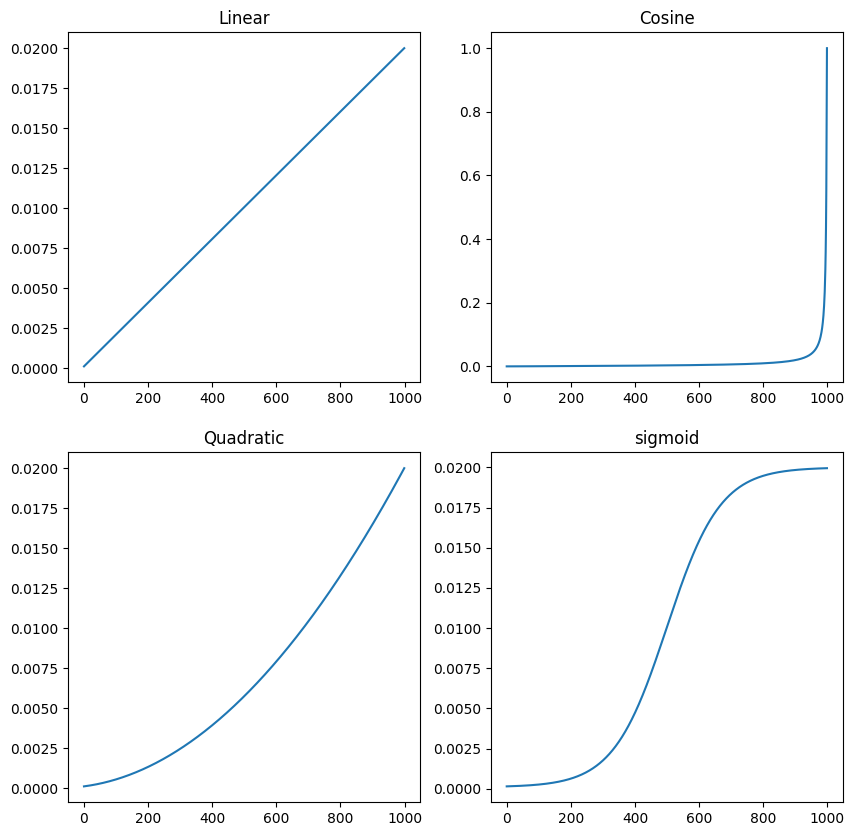

In [6]:
timesteps = 1000

fig, ax = plt.subplots(2, 2, figsize=(10, 10))


ax[0][0].plot(linear_beta_schedule(timesteps))
ax[0][1].plot(cosine_beta_schedule(timesteps))
ax[1][0].plot(quadratic_beta_schedule(timesteps))
ax[1][1].plot(sigmoid_beta_schedule(timesteps))

ax[0][0].set(title=f"Linear")
ax[0][1].set(title=f"Cosine")
ax[1][0].set(title=f"Quadratic")
ax[1][1].set(title=f"sigmoid")

In [7]:
train_transform = T.Compose([
    T.RandomHorizontalFlip(p=0.5),
    T.RandomVerticalFlip(p=0.5),
    T.RandomChoice([
        T.Lambda(lambda x: x),                          # 0°
        T.Lambda(lambda x: x.rotate(90, expand=False)),   # 90°
        T.Lambda(lambda x: x.rotate(180, expand=False)),  # 180°
        T.Lambda(lambda x: x.rotate(270, expand=False)),  # 270°
    ]),
    T.ColorJitter(brightness=0.05, contrast=0.05),
    T.RandomApply([T.GaussianBlur(3, (0.1, 0.3))], p=0.05),
    T.Resize((64, 64)),  # Для надёжности (изображения EuroSAT уже 64×64)
    T.ToTensor(),
    T.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])  # → [-1, 1]
])

val_transform = T.Compose([
    T.Resize((64, 64)),
    T.ToTensor(),
    T.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])
# Создание датасетов
train_dataset = EuroSATDataset(
    csv_path=os.path.join(img_path, "train.csv"),
    image_root=img_path,
    transform=train_transform,
    return_label=True
)

val_dataset = EuroSATDataset(
    csv_path=os.path.join(img_path, "validation.csv"),
    image_root=img_path,
    transform=val_transform,
    return_label=True
)

print(f"Train dataset size: {len(train_dataset)}")
print(f"Validation dataset size: {len(val_dataset)}")

Train dataset size: 18900
Validation dataset size: 5400


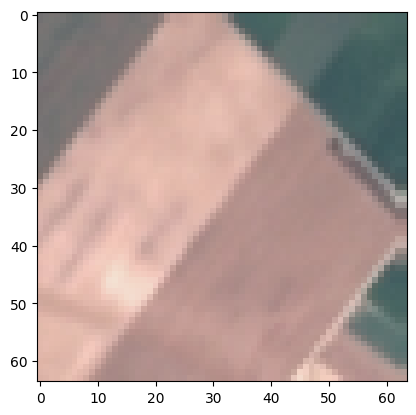

In [8]:
plt.imshow((train_dataset[0][0].permute(1, 2, 0) + 1) / 2)

## Class for DDPM

In [9]:
class DDPM:
    def __init__(self, beta_schedule, model=None, device='cpu'):
        self.beta_schedule = beta_schedule
        self.alpha_schedule = 1 - beta_schedule
        self.alpha_hat_schedule = torch.cumprod(self.alpha_schedule, dim=0)
        self.model = model
        self.device = device

        self.beta_schedule = self.beta_schedule.to(device)
        self.alpha_schedule = self.alpha_schedule.to(device)
        self.alpha_hat_schedule = self.alpha_hat_schedule.to(device)
        self.timesteps = len(self.beta_schedule)

    def forward_process(self, x_0, t):
        """
        x_0: [B, C, H, W] - батч чистых картинок
        t:   [B]           - батч случайных таймстепов
        """
        # 1. Генерируем случайный шум для всего батча
        eps = torch.randn_like(x_0)

        # 2. Выбираем нужные альфа-хэт для каждого элемента в батче
        # alpha_t будет иметь форму (B,)
        alpha_t = self.alpha_hat_schedule[t.cpu()]

        # 3. Растягиваем (B,) до (B, 1, 1, 1), чтобы сработало умножение (broadcasting)
        # Это делается через .view(-1, 1, 1, 1) или [:, None, None, None]
        alpha_t = alpha_t.view(-1, 1, 1, 1)

        # 4. Формула диффузии
        noisy_x = torch.sqrt(alpha_t) * x_0 + torch.sqrt(1 - alpha_t) * eps
        
        return noisy_x, eps

    def generate_timesteps(self, x_0):
        return torch.randint(self.timesteps, (x_0.shape[0], ))


Text(0.5, 0.98, 'Image noising on timestep 300')

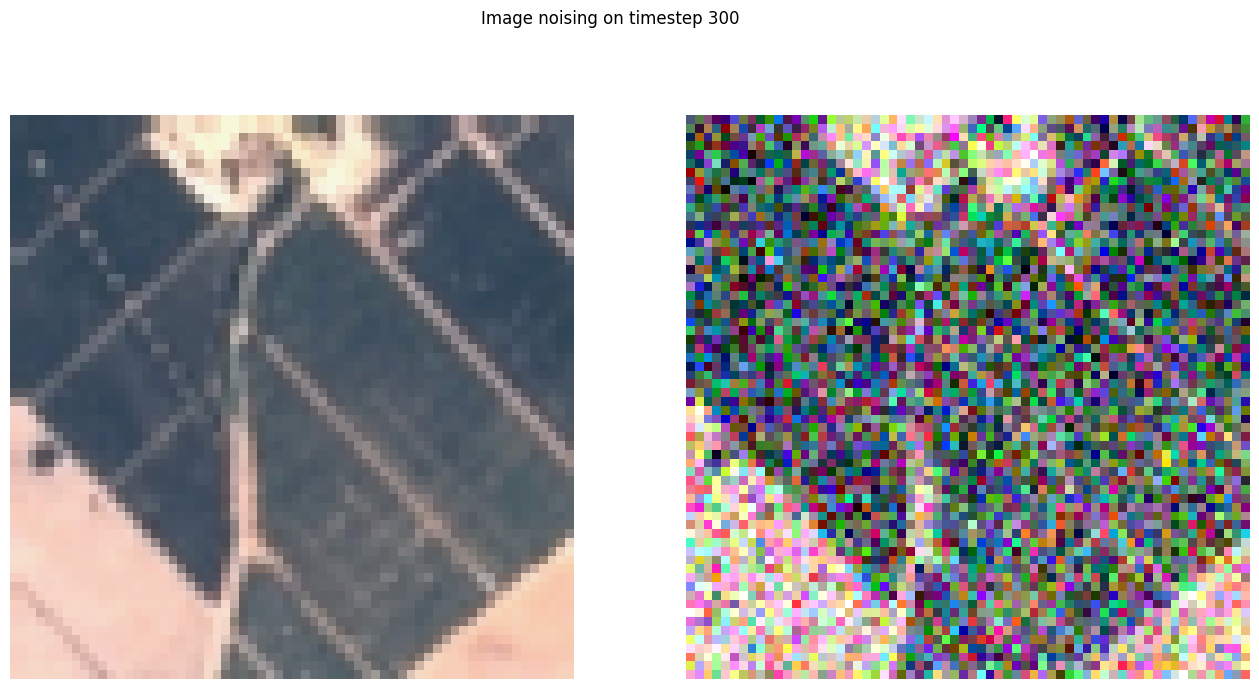

In [10]:
timesteps = 1000
beta_schedule = cosine_beta_schedule(timesteps)

ddpm = DDPM(beta_schedule)

imag = train_dataset[torch.randint(len(train_dataset), (1,))][0].permute(1, 2, 0)

# timestep = torch.randint(timesteps, (1, ))
timestep = torch.tensor([300])
noised_imag, _ = ddpm.forward_process(imag, timestep)

fig, ax = plt.subplots(1, 2, figsize=(16, 8))

ax[0].axis('off')
ax[0].imshow((imag + 1) / 2)

ax[1].axis('off')
ax[1].imshow(torch.clamp((noised_imag[0] + 1) / 2, 0, 1))

fig.suptitle(f"Image noising on timestep {timestep[0]}")

## Train loop

In [11]:
def train_ddpm(ddpm, train_dataset, val_dataset, optimizer, device, info_interval=5,
                  epochs=50, batch_size=128):
    train_loader = DataLoader(train_dataset, batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size)
    criterion = nn.MSELoss() 
    
    for epoch in range(epochs):
        model.train()
        
        pbar = tqdm(train_loader, desc=f"Epoch {epoch}/{epochs} [Train]", leave=False)

        total_train_loss = 0
        for data, labels, _ in pbar:
            data, labels = data.to(device), labels.to(device)
            optimizer.zero_grad()
            
            t = ddpm.generate_timesteps(data).to(device)
            noisy_data, noise = ddpm.forward_process(data, t)

            noise_pred = ddpm.model(noisy_data.to(device), t.to(device), labels)

            loss = criterion(noise_pred, noise)

            total_train_loss += loss.item()
            
            loss.backward()
            optimizer.step()
            
            pbar.set_postfix({
                'Loss': f"{loss.item():.5f}"
            })
            
        # --- ФАЗА ВАЛИДАЦИИ ---
        model.eval()

        total_val_loss = 0
        with torch.no_grad():
            for data, labels, _ in tqdm(val_loader, desc='Validation', leave=False):
                data, labels = data.to(device), labels.to(device)

                t = ddpm.generate_timesteps(data).to(device)
                noisy_data, noise = ddpm.forward_process(data, t)
    
                noise_pred = ddpm.model(noisy_data.to(device), t.to(device), labels)
    
                loss = criterion(noise_pred, noise)

                total_val_loss += loss.item()
                

        if epoch % info_interval == 0:
            tqdm.write(f"Train loss: {total_train_loss / len(train_loader)} | Val loss: {total_val_loss / len(val_loader)}")
    # return history

In [12]:
def print_gpu_memory():
    if torch.cuda.is_available():
        # Текущая выделенная память под тензоры
        allocated = torch.cuda.memory_allocated() / 1024**2
       c # Память, зарезервированная кэшем PyTorch
        reserved = torch.cuda.memory_reserved() / 1024**2
        # Максимальная память, которую PyTorch занимал за всё время работы скрипта
        max_allocated = torch.cuda.max_memory_allocated() / 1024**2
        
        print(f"--- GPU Memory Report ---")
        print(f"Занято тензорами: {allocated:.2f} MB")
        print(f"Зарезервировано:  {reserved:.2f} MB")
        print(f"Пик за всё время: {max_allocated:.2f} MB")
        print(f"-------------------------")

In [13]:


# Параметры обучения
batch_size = 48
epochs = 15
learning_rate = 5e-4
info_interval = 1

# Устройство
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")



# Создание модели
timesteps = 500
beta_schedule = cosine_beta_schedule(timesteps)
model = UNet(n_channels = 16).to(device)
ddpm = DDPM(beta_schedule, model, device)


# Создание оптимизатора
optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate)

print_gpu_memory()


Using device: cuda
--- GPU Memory Report ---
Занято тензорами: 40.79 MB
Зарезервировано:  52.00 MB
Пик за всё время: 40.79 MB
-------------------------


In [14]:
train_ddpm(ddpm, train_dataset, val_dataset, optimizer, device, batch_size=batch_size, epochs=epochs, info_interval=info_interval)

Epoch 0/15 [Train]:   0%|          | 0/394 [00:00<?, ?it/s]

Validation:   0%|          | 0/113 [00:00<?, ?it/s]

Train loss: 0.16058827850608354 | Val loss: 0.054432263053887715


Epoch 1/15 [Train]:   0%|          | 0/394 [00:00<?, ?it/s]

Validation:   0%|          | 0/113 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/113 [00:00<?, ?it/s]

Train loss: 0.028376314973430284 | Val loss: 0.027017457831024595


Epoch 14/15 [Train]:   0%|          | 0/394 [00:00<?, ?it/s]

Validation:   0%|          | 0/113 [00:00<?, ?it/s]

Train loss: 0.02788919761190711 | Val loss: 0.027598699694911463


In [29]:
imag_shape = train_dataset[0][0].shape 
noise = torch.randn((1, *imag_shape), device=device)
curr_imag = noise
label = torch.randint(10, (1, ))

# 3. Sampling Loop
with torch.no_grad():
    for timestep in torch.arange(450 - 1, -1, -1):
        t = torch.full((1,), timestep, dtype=torch.long, device=device)
        
        # 1. Predict noise
        eps = ddpm.model(curr_imag, t, label)
        
        # 2. Get schedule values for this timestep
        # Ensure these are tensors on the correct device
        alpha_t = ddpm.alpha_schedule[t]
        alpha_hat_t = ddpm.alpha_hat_schedule[t]
        beta_t = ddpm.beta_schedule[t]
        
        # 3. Calculate Mean (mu_theta)
        # Formula: 1/sqrt(alpha) * (x_t - (beta / sqrt(1 - alpha_hat)) * eps)
        coef1 = 1.0 / torch.sqrt(alpha_t)
        coef2 = beta_t / torch.sqrt(1.0 - alpha_hat_t)
        
        mean = coef1 * (curr_imag - coef2 * eps)
        
        # 4. Calculate Variance / Add Noise
        # If t > 0, add noise. If t == 0, sigma = 0 (no noise)
        if timestep > 0:
            noise = torch.randn_like(curr_imag)
            variance = torch.sqrt(beta_t) * noise
            curr_imag = mean + variance
        else:
            curr_imag = mean

        # Optional: Print progress
        print(f"Timestep: {timestep}, EPS Shape: {eps.shape}")

# curr_imag now contains the generated image at t=0
generated_image = torch.clamp(curr_imag.squeeze(0).cpu(), -1, 1)

Timestep: 449, EPS Shape: torch.Size([1, 3, 64, 64])
Timestep: 448, EPS Shape: torch.Size([1, 3, 64, 64])
Timestep: 447, EPS Shape: torch.Size([1, 3, 64, 64])
Timestep: 446, EPS Shape: torch.Size([1, 3, 64, 64])
Timestep: 445, EPS Shape: torch.Size([1, 3, 64, 64])
Timestep: 444, EPS Shape: torch.Size([1, 3, 64, 64])
Timestep: 443, EPS Shape: torch.Size([1, 3, 64, 64])
Timestep: 442, EPS Shape: torch.Size([1, 3, 64, 64])
Timestep: 441, EPS Shape: torch.Size([1, 3, 64, 64])
Timestep: 440, EPS Shape: torch.Size([1, 3, 64, 64])
Timestep: 439, EPS Shape: torch.Size([1, 3, 64, 64])
Timestep: 438, EPS Shape: torch.Size([1, 3, 64, 64])
Timestep: 437, EPS Shape: torch.Size([1, 3, 64, 64])
Timestep: 436, EPS Shape: torch.Size([1, 3, 64, 64])
Timestep: 435, EPS Shape: torch.Size([1, 3, 64, 64])
Timestep: 434, EPS Shape: torch.Size([1, 3, 64, 64])
Timestep: 433, EPS Shape: torch.Size([1, 3, 64, 64])
Timestep: 432, EPS Shape: torch.Size([1, 3, 64, 64])
Timestep: 431, EPS Shape: torch.Size([1, 3, 64

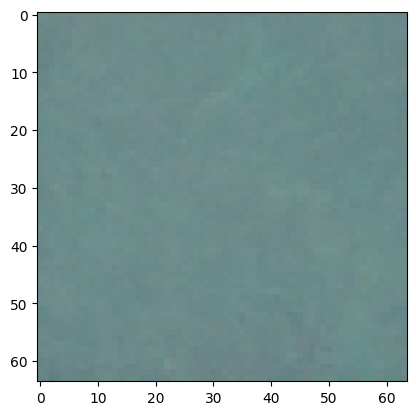

In [30]:
plt.imshow((generated_image.permute(1, 2, 0) + 1) / 2)

Iterating through labels:   0%|          | 0/10 [00:00<?, ?it/s]

Sampling process:   0%|          | 0/400 [00:00<?, ?it/s]

Sampling process:   0%|          | 0/400 [00:00<?, ?it/s]

Sampling process:   0%|          | 0/400 [00:00<?, ?it/s]

Sampling process:   0%|          | 0/400 [00:00<?, ?it/s]

...

Sampling process:   0%|          | 0/400 [00:00<?, ?it/s]

Sampling process:   0%|          | 0/400 [00:00<?, ?it/s]

Sampling process:   0%|          | 0/400 [00:00<?, ?it/s]

Sampling process:   0%|          | 0/400 [00:00<?, ?it/s]

Sampling process:   0%|          | 0/400 [00:00<?, ?it/s]

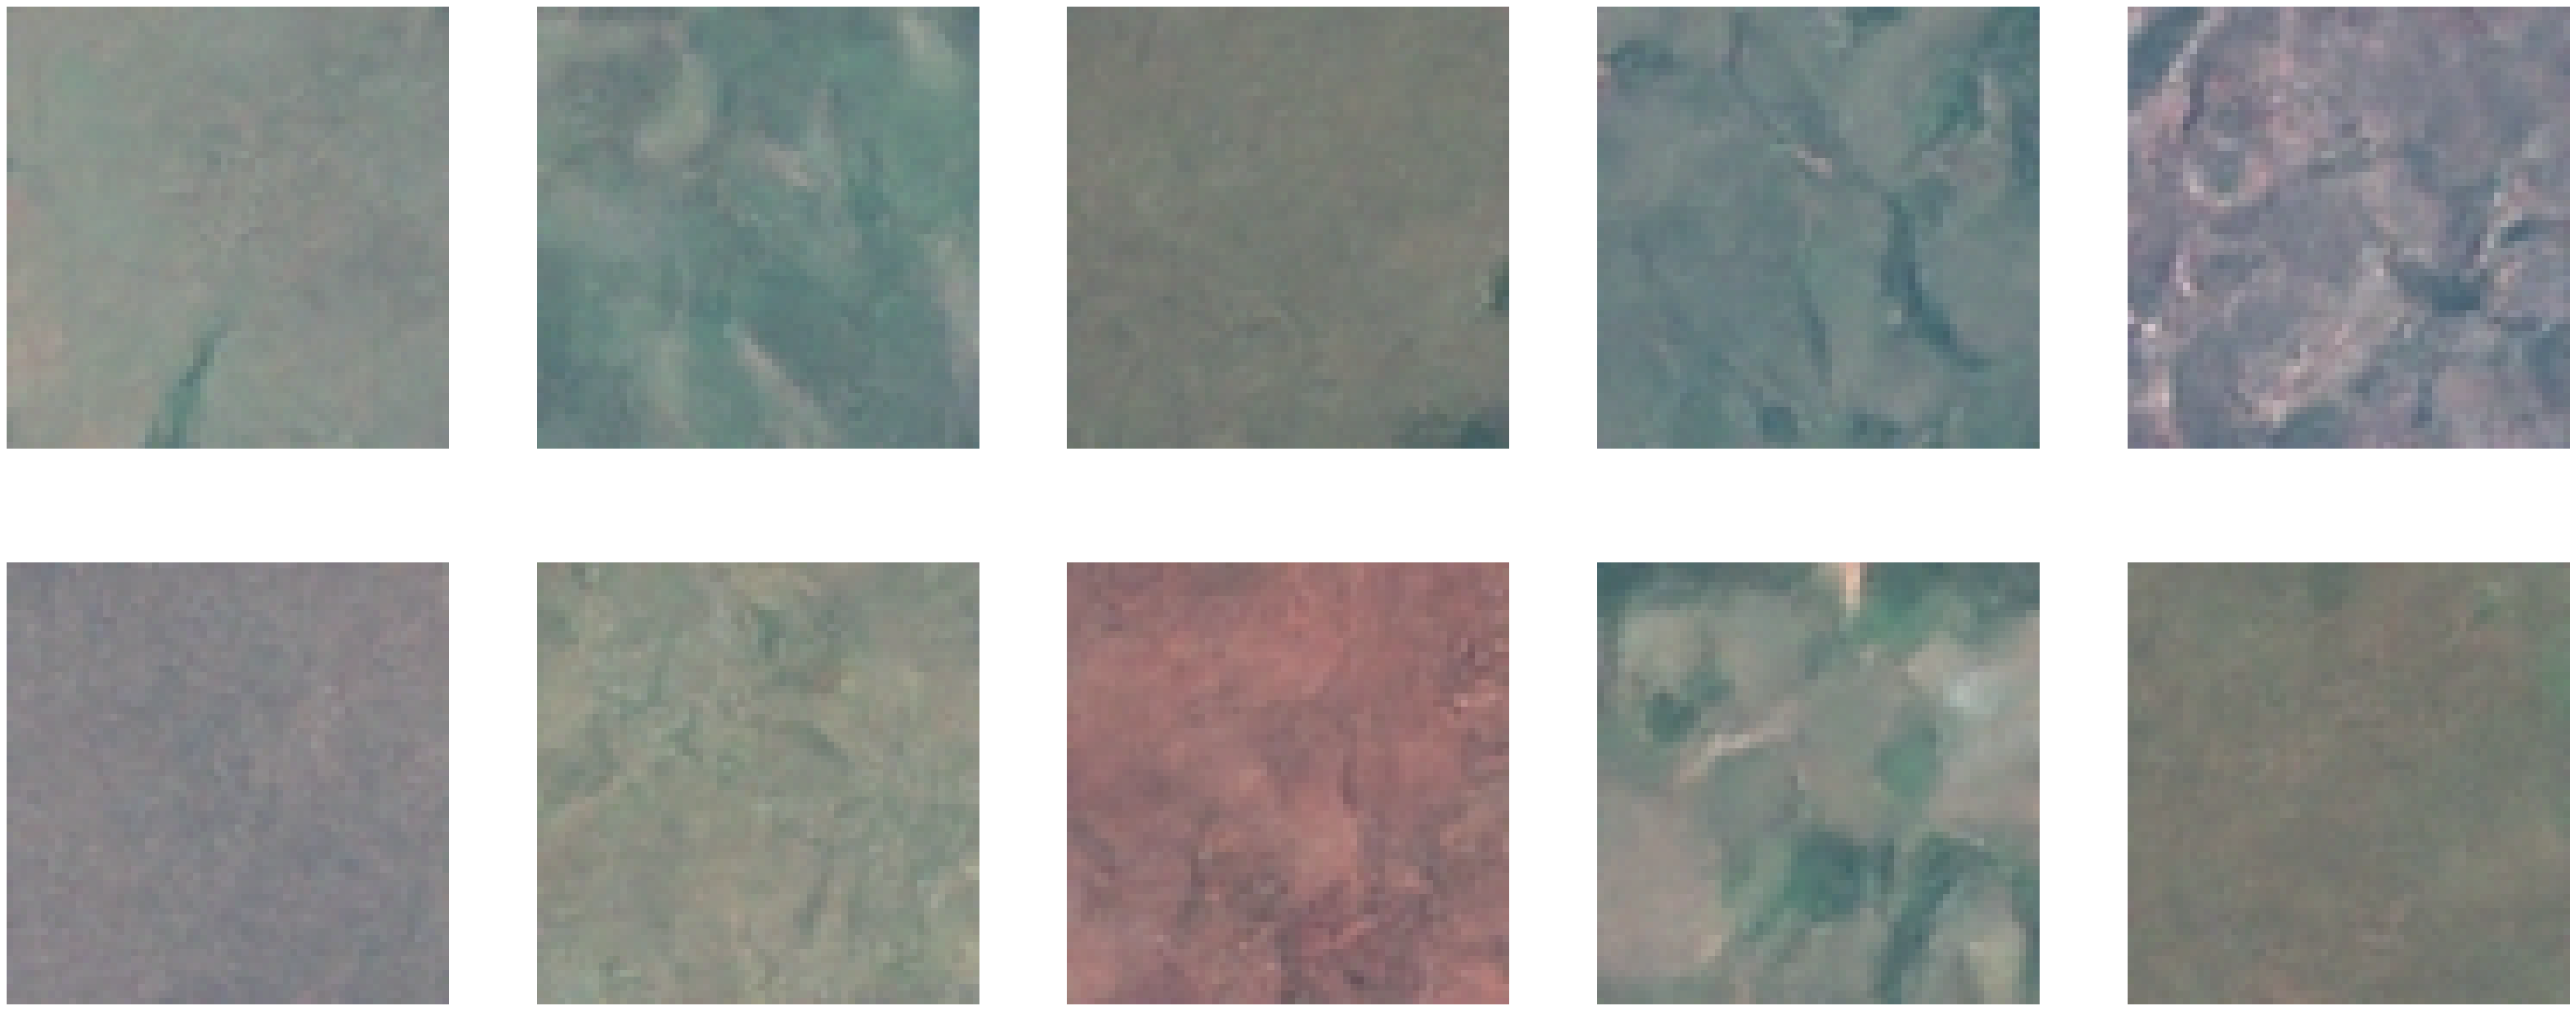

In [37]:
fig, ax = plt.subplots(2, 5, figsize=(50, 20))

for i in tqdm(range(10), desc=f"Iterating through labels", leave=False):
    imag_shape = train_dataset[0][0].shape 
    noise = torch.randn((1, *imag_shape), device=device)
    curr_imag = noise
    label = torch.tensor([i]).view(-1, 1)
    
    # 3. Sampling Loop
    with torch.no_grad():
        for timestep in tqdm(torch.arange(400 - 1, -1, -1), desc=f"Sampling process"):
            t = torch.full((1,), timestep, dtype=torch.long, device=device)
            
            # 1. Predict noise
            eps = ddpm.model(curr_imag, t, label)
            
            # 2. Get schedule values for this timestep
            # Ensure these are tensors on the correct device
            alpha_t = ddpm.alpha_schedule[t]
            alpha_hat_t = ddpm.alpha_hat_schedule[t]
            beta_t = ddpm.beta_schedule[t]
            
            # 3. Calculate Mean (mu_theta)
            # Formula: 1/sqrt(alpha) * (x_t - (beta / sqrt(1 - alpha_hat)) * eps)
            coef1 = 1.0 / torch.sqrt(alpha_t)
            coef2 = beta_t / torch.sqrt(1.0 - alpha_hat_t)
            
            mean = coef1 * (curr_imag - coef2 * eps)
            
            # 4. Calculate Variance / Add Noise
            # If t > 0, add noise. If t == 0, sigma = 0 (no noise)
            if timestep > 0:
                noise = torch.randn_like(curr_imag)
                variance = torch.sqrt(beta_t) * noise
                curr_imag = mean + variance
            else:
                curr_imag = mean
    
    # curr_imag now contains the generated image at t=0
    generated_image = torch.clamp(curr_imag.squeeze(0).cpu(), -1, 1)
    ax[i // 5][i % 5].axis('off')
    ax[i // 5][i % 5].imshow((generated_image.permute(1, 2, 0) + 1) / 2)

## Save/Load functions

In [26]:
def save_model(model, path, metadata=None):
    """Сохраняет модель и опциональные метаданные"""
    torch.save({
        'model_state_dict': model.state_dict(),
        'metadata': metadata or {}
    }, path)

def load_model_SOM(path, device='cpu'):
    """Загружает модель на указанный девайс"""
    
    checkpoint = torch.load(path, map_location=device)
    model = EuroSAT_GlobalSOM_Deep()  # передай свои параметры при необходимости
    model.load_state_dict(checkpoint['model_state_dict'])
    model.to(device)
    model.eval()
    return model, checkpoint['metadata']

In [ ]:
save_model(ddpm.model, "checkpoints_ddpm/base.pth", {"epochs": 15, "lr": 5e-4, "batch_size": 48})

# UNet based DDPM refiner on SOM-VAE

## Imports

In [1]:
import optuna

# Основные библиотеки
import numpy as np
import matplotlib.pyplot as plt

# PyTorch
import torch
from torch import nn
from torch.functional import F
import torchvision.transforms as T
from torch.utils.data import Dataset, DataLoader

# Обработка данных
import polars as pl
import os
from PIL import Image
from pathlib import Path

import random
# Метрики
from sklearn.metrics import normalized_mutual_info_score

# Прогресс-бары
from tqdm.notebook import tqdm

# Загрузка датасетов
import kagglehub

import math
import os
from typing import Optional, Tuple, Union, List

In [3]:
# Download latest version
path = kagglehub.dataset_download("apollo2506/eurosat-dataset")

print("Path to dataset files:", path)
img_path = os.path.join(path, "EuroSAT")

Path to dataset files: /home/mihalko711/.cache/kagglehub/datasets/apollo2506/eurosat-dataset/versions/6


## Создание Dataset класса

In [4]:
class EuroSATDataset(Dataset):
    def __init__(self, csv_path, image_root, transform=None, filt_class=None, return_label=False):
        self.df = pl.read_csv(csv_path).drop(pl.read_csv(csv_path).columns[0])
        self.image_root = Path(image_root)
        self.transform = transform  # ← внешний трансформ
        self.return_label = return_label

        if filt_class is not None:
            self.df = self.df.filter(pl.col("Label") == filt_class)
            
    def __len__(self):
        return self.df.height

    def __getitem__(self, idx):
        row = self.df.row(idx, named=True)

        img_path = self.image_root / row["Filename"]
        image = Image.open(img_path).convert("RGB")
        
        if self.transform:
            image = self.transform(image)  # ← применяем внешний трансформ

        if self.return_label:
            return image, row["Label"], row["ClassName"]

        return image

In [5]:
train_transform = T.Compose([
    T.RandomHorizontalFlip(p=0.5),
    T.RandomVerticalFlip(p=0.5),
    T.RandomChoice([
        T.Lambda(lambda x: x),                          # 0°
        T.Lambda(lambda x: x.rotate(90, expand=False)),   # 90°
        T.Lambda(lambda x: x.rotate(180, expand=False)),  # 180°
        T.Lambda(lambda x: x.rotate(270, expand=False)),  # 270°
    ]),
    T.ColorJitter(brightness=0.05, contrast=0.05),
    T.RandomApply([T.GaussianBlur(3, (0.1, 0.3))], p=0.05),
    T.Resize((64, 64)),  # Для надёжности (изображения EuroSAT уже 64×64)
    T.ToTensor(),
    T.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])  # → [-1, 1]
])

val_transform = T.Compose([
    T.Resize((64, 64)),
    T.ToTensor(),
    T.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])
# Создание датасетов
train_dataset = EuroSATDataset(
    csv_path=os.path.join(img_path, "train.csv"),
    image_root=img_path,
    transform=train_transform,
    return_label=True
)

val_dataset = EuroSATDataset(
    csv_path=os.path.join(img_path, "validation.csv"),
    image_root=img_path,
    transform=val_transform,
    return_label=True
)

print(f"Train dataset size: {len(train_dataset)}")
print(f"Validation dataset size: {len(val_dataset)}")

Train dataset size: 18900
Validation dataset size: 5400


## Классы SOM-VAE

In [6]:
class GlobalSOMLayer(nn.Module):
    def __init__(self, grid_h, grid_w, channels, latent_h, latent_w):
        super().__init__()
        self.grid_h, self.grid_w = grid_h, grid_w
        self.c, self.h, self.w = channels, latent_h, latent_w
        self.template_dim = channels * latent_h * latent_w
        
        self.embeddings = nn.Parameter(torch.randn(grid_h * grid_w, self.template_dim) * 1e-2)

        indices = torch.arange(grid_h * grid_w)
        # Соседи: left, up, right, down
        ln = torch.where(indices % grid_w == 0, -1, indices - 1)
        rn = torch.where(indices % grid_w == grid_w - 1, -1, indices + 1)
        un = torch.where(indices < grid_w, -1, indices - grid_w)
        dn = torch.where(indices >= (grid_h - 1) * grid_w, -1, indices + grid_w)
        
        self.register_buffer('neighbors_indices', torch.stack([ln, un, rn, dn], dim=1))
        self.register_buffer('valid_mask', (self.neighbors_indices != -1).float())
        
    def get_neighbors(self, indices):
        return self.neighbors_indices[indices]

    def forward(self, z_e, stochastic=True):
        batch_size = z_e.size(0)
        z_e_flat = z_e.view(batch_size, -1)
        
        # Расстояния до всех узлов
        distances = torch.cdist(z_e_flat, self.embeddings) # [B, N]
        bmu_indices = torch.argmin(distances, dim=1)
        
        if not stochastic:
            z_q_flat = self.embeddings[bmu_indices]
        else:
            # Получаем индексы и маски соседей для батча
            n_idx = self.get_neighbors(bmu_indices) # [B, 4]
            mask = self.valid_mask[bmu_indices]     # [B, 4]
            
            # Расстояния до соседей (используем clamp, чтобы не выйти за границы при индексе -1)
            dist_n = torch.gather(distances, 1, n_idx.clamp(min=0)) * mask
            
            # Веса соседей: (1 - d_i / d_max)
            d_max = dist_n.max(dim=1, keepdim=True)[0]
            w_n = (1.0 - dist_n / (d_max + 1e-8)) * mask
            
            # Вес победителя всегда 1.0
            w_bmu = torch.ones(batch_size, 1, device=z_e.device)
            
            # Собираем все веса и эмбеддинги
            all_w = torch.cat([w_bmu, w_n], dim=1) # [B, 5]
            all_w = all_w / all_w.sum(dim=1, keepdim=True)
            
            emb_bmu = self.embeddings[bmu_indices].unsqueeze(1)    # [B, 1, D]
            emb_n = self.embeddings[n_idx.clamp(min=0)]           # [B, 4, D]
            all_emb = torch.cat([emb_bmu, emb_n], dim=1)           # [B, 5, D]
            
            # Итоговый латент как взвешенная сумма
            z_q_flat = (all_emb * all_w.unsqueeze(-1)).sum(dim=1)
        
        return (
            self.embeddings[bmu_indices].view(batch_size, self.c, self.h, self.w),
            z_q_flat.view(batch_size, self.c, self.h, self.w),
            bmu_indices
        )

    def calc_activations(self, z_e):
        distances = torch.cdist(z_e.view(z_e.size(0), -1), self.embeddings)
        return 1.0 / (distances + 1e-8)

In [7]:
class ResBlock(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(channels, channels, 3, padding=1),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(channels, channels, 3, padding=1),
        )

    def forward(self, x):
        return x + self.block(x)


class EuroSAT_GlobalSOM_Deep(nn.Module):
    def __init__(self, in_channels=3, grid_size=(16, 16), latent_dim=(32, 8, 8), num_classes=10):
        super().__init__()
        c_l, h_l, w_l = latent_dim

        # ---------------------
        # 1. ENCODER (64x64 -> 8x8)
        # ---------------------
        self.encoder = nn.Sequential(
            # 64 -> 32
            nn.Conv2d(in_channels, 32, 4, stride=2, padding=1),
            nn.LeakyReLU(0.2, inplace=True),

            # 32 -> 16
            nn.Conv2d(32, 64, 4, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.2, inplace=True),

            # 16 -> 8
            nn.Conv2d(64, 128, 4, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),

            # feature refinement at 8x8
            nn.Conv2d(128, 128, 3, padding=1),
            nn.LeakyReLU(0.2, inplace=True),

            # channel projection to latent
            nn.Conv2d(128, c_l, 1)
        )

        # ---------------------
        # 2. SOM LAYER
        # ---------------------
        self.som = GlobalSOMLayer(grid_size[0], grid_size[1], c_l, h_l, w_l)

        # ---------------------
        # 3. DECODER (8x8 -> 64x64)
        # ---------------------
        self.decoder = nn.Sequential(
            # latent refinement — ОЧЕНЬ правильно, что он у тебя есть
            nn.Conv2d(c_l, 128, 3, padding=1),
            nn.LeakyReLU(0.2, inplace=True),
            ResBlock(128),
        
            # 8 -> 16
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False),
            nn.Conv2d(128, 128, 3, padding=1),
            nn.LeakyReLU(0.2, inplace=True),
            ResBlock(128),
        
            # 16 -> 32
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False),
            nn.Conv2d(128, 64, 3, padding=1),
            nn.LeakyReLU(0.2, inplace=True),
            ResBlock(64),
        
            # 32 -> 64
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False),
            nn.Conv2d(64, 32, 3, padding=1),
            nn.LeakyReLU(0.2, inplace=True),
            ResBlock(32),
        
            nn.Conv2d(32, in_channels, 3, padding=1),
            nn.Tanh()
        )



    def forward(self, x):
        z_e = self.encoder(x)
        z_q, z_q_sample, indices = self.som(z_e)
        x_hat_e = self.decoder(z_e)
        x_hat_q = self.decoder(z_q_sample)
        return x_hat_e, x_hat_q, z_e, z_q, indices

    def decode(self, z):
        return self.decoder(z)


## Save/Load functions

In [8]:
def save_model(model, path, metadata=None):
    """Сохраняет модель и опциональные метаданные"""
    torch.save({
        'model_state_dict': model.state_dict(),
        'metadata': metadata or {}
    }, path)

def load_model_SOM(path, device='cpu'):
    """Загружает модель на указанный девайс"""
    
    checkpoint = torch.load(path, map_location=device)
    model = EuroSAT_GlobalSOM_Deep()  # передай свои параметры при необходимости
    model.load_state_dict(checkpoint['model_state_dict'])
    model.to(device)
    model.eval()
    return model, checkpoint['metadata']

## Non-conditional UNet

In [9]:
class TimeEmbedding(nn.Module):
    """
    ### Embeddings for $t$
    """

    def __init__(self, n_channels: int):
        """
        * `n_channels` is the number of dimensions in the embedding
        """
        super().__init__()
        self.n_channels = n_channels
        # First linear layer
        self.lin1 = nn.Linear(self.n_channels // 4, self.n_channels)
        # Activation
        self.act = nn.SiLU()
        # Second linear layer
        self.lin2 = nn.Linear(self.n_channels, self.n_channels)

    def forward(self, t: torch.Tensor):
        # Create sinusoidal position embeddings
        half_dim = self.n_channels // 8
        emb = math.log(10_000) / (half_dim - 1)
        emb = torch.exp(torch.arange(half_dim, device=t.device) * -emb)
        emb = t[:, None] * emb[None, :]
        emb = torch.cat((emb.sin(), emb.cos()), dim=1)

        # Transform with the MLP
        emb = self.act(self.lin1(emb))
        emb = self.lin2(emb)

        #
        return emb


class ResidualBlock(nn.Module):
    """
    ### Residual block

    A residual block has two convolution layers with group normalization.
    Each resolution is processed with two residual blocks.
    """

    def __init__(self, in_channels: int, out_channels: int, time_channels: int,
                 n_groups: int = 16, dropout: float = 0.1):
        """
        * `in_channels` is the number of input channels
        * `out_channels` is the number of input channels
        * `time_channels` is the number channels in the time step ($t$) embeddings
        * `n_groups` is the number of groups for [group normalization](../../normalization/group_norm/index.html)
        * `dropout` is the dropout rate
        """
        super().__init__()
        # Group normalization and the first convolution layer
        self.norm1 = nn.GroupNorm(n_groups, in_channels)
        self.act1 = nn.SiLU()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=(3, 3), padding=(1, 1))

        # Group normalization and the second convolution layer
        self.norm2 = nn.GroupNorm(n_groups, out_channels)
        self.act2 = nn.SiLU()
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=(3, 3), padding=(1, 1))

        # If the number of input channels is not equal to the number of output channels we have to
        # project the shortcut connection
        if in_channels != out_channels:
            self.shortcut = nn.Conv2d(in_channels, out_channels, kernel_size=(1, 1))
        else:
            self.shortcut = nn.Identity()

        # Linear layer for time embeddings
        self.time_emb = nn.Linear(time_channels, out_channels)
        self.time_act = nn.SiLU()

        self.dropout = nn.Dropout(dropout)

    def forward(self, x: torch.Tensor, t: torch.Tensor):
        """
        * `x` has shape `[batch_size, in_channels, height, width]`
        * `t` has shape `[batch_size, time_channels]`
        """
        # First convolution layer
        h = self.conv1(self.act1(self.norm1(x)))
        # Add time embeddings
        h += self.time_emb(self.time_act(t))[:, :, None, None]
        # Second convolution layer
        h = self.conv2(self.dropout(self.act2(self.norm2(h))))

        # Add the shortcut connection and return
        return h + self.shortcut(x)


class AttentionBlock(nn.Module):
    """
    ### Attention block

    This is similar to [transformer multi-head attention](../../transformers/mha.html).
    """

    def __init__(self, n_channels: int, n_heads: int = 1, d_k: int = None, n_groups: int = 16):
        """
        * `n_channels` is the number of channels in the input
        * `n_heads` is the number of heads in multi-head attention
        * `d_k` is the number of dimensions in each head
        * `n_groups` is the number of groups for [group normalization](../../normalization/group_norm/index.html)
        """
        super().__init__()

        # Default `d_k`
        if d_k is None:
            d_k = n_channels
        # Normalization layer
        self.norm = nn.GroupNorm(n_groups, n_channels)
        # Projections for query, key and values
        self.projection = nn.Linear(n_channels, n_heads * d_k * 3)
        # Linear layer for final transformation
        self.output = nn.Linear(n_heads * d_k, n_channels)
        # Scale for dot-product attention
        self.scale = d_k ** -0.5
        #
        self.n_heads = n_heads
        self.d_k = d_k

    def forward(self, x: torch.Tensor, t: Optional[torch.Tensor] = None):
        """
        * `x` has shape `[batch_size, in_channels, height, width]`
        * `t` has shape `[batch_size, time_channels]`
        """
        # `t` is not used, but it's kept in the arguments because for the attention layer function signature
        # to match with `ResidualBlock`.
        _ = t
        # Get shape
        batch_size, n_channels, height, width = x.shape
        # Change `x` to shape `[batch_size, seq, n_channels]`
        x = x.view(batch_size, n_channels, -1).permute(0, 2, 1)
        # Get query, key, and values (concatenated) and shape it to `[batch_size, seq, n_heads, 3 * d_k]`
        qkv = self.projection(x).view(batch_size, -1, self.n_heads, 3 * self.d_k)
        # Split query, key, and values. Each of them will have shape `[batch_size, seq, n_heads, d_k]`
        q, k, v = torch.chunk(qkv, 3, dim=-1)
        # Calculate scaled dot-product $\frac{Q K^\top}{\sqrt{d_k}}$
        attn = torch.einsum('bihd,bjhd->bijh', q, k) * self.scale
        # Softmax along the sequence dimension $\underset{seq}{softmax}\Bigg(\frac{Q K^\top}{\sqrt{d_k}}\Bigg)$
        attn = attn.softmax(dim=2)
        # Multiply by values
        res = torch.einsum('bijh,bjhd->bihd', attn, v)
        # Reshape to `[batch_size, seq, n_heads * d_k]`
        res = res.view(batch_size, -1, self.n_heads * self.d_k)
        # Transform to `[batch_size, seq, n_channels]`
        res = self.output(res)

        # Add skip connection
        res += x

        # Change to shape `[batch_size, in_channels, height, width]`
        res = res.permute(0, 2, 1).view(batch_size, n_channels, height, width)

        #
        return res


class DownBlock(nn.Module):
    """
    ### Down block

    This combines `ResidualBlock` and `AttentionBlock`. These are used in the first half of U-Net at each resolution.
    """

    def __init__(self, in_channels: int, out_channels: int, time_channels: int, has_attn: bool):
        super().__init__()
        self.res = ResidualBlock(in_channels, out_channels, time_channels)
        if has_attn:
            self.attn = AttentionBlock(out_channels)
        else:
            self.attn = nn.Identity()

    def forward(self, x: torch.Tensor, t: torch.Tensor):
        x = self.res(x, t)
        x = self.attn(x)
        return x


class UpBlock(nn.Module):
    """
    ### Up block

    This combines `ResidualBlock` and `AttentionBlock`. These are used in the second half of U-Net at each resolution.
    """

    def __init__(self, in_channels: int, out_channels: int, time_channels: int, has_attn: bool):
        super().__init__()
        # The input has `in_channels + out_channels` because we concatenate the output of the same resolution
        # from the first half of the U-Net
        self.res = ResidualBlock(in_channels + out_channels, out_channels, time_channels)
        if has_attn:
            self.attn = AttentionBlock(out_channels)
        else:
            self.attn = nn.Identity()

    def forward(self, x: torch.Tensor, t: torch.Tensor):
        x = self.res(x, t)
        x = self.attn(x)
        return x


class MiddleBlock(nn.Module):
    """
    ### Middle block

    It combines a `ResidualBlock`, `AttentionBlock`, followed by another `ResidualBlock`.
    This block is applied at the lowest resolution of the U-Net.
    """

    def __init__(self, n_channels: int, time_channels: int):
        super().__init__()
        self.res1 = ResidualBlock(n_channels, n_channels, time_channels)
        self.attn = AttentionBlock(n_channels)
        self.res2 = ResidualBlock(n_channels, n_channels, time_channels)

    def forward(self, x: torch.Tensor, t: torch.Tensor):
        x = self.res1(x, t)
        x = self.attn(x)
        x = self.res2(x, t)
        return x


class Upsample(nn.Module):
    """
    ### Scale up the feature map by $2 \times$
    """

    def __init__(self, n_channels):
        super().__init__()
        self.upsample = nn.Sequential(
            nn.Upsample(scale_factor=2, mode='nearest'), # или 'bilinear'
            nn.Conv2d(n_channels, n_channels, kernel_size=3, padding=1)
        )

    def forward(self, x: torch.Tensor, t: torch.Tensor):
        # `t` is not used, but it's kept in the arguments because for the attention layer function signature
        # to match with `ResidualBlock`.
        _ = t
        return self.upsample(x)


class Downsample(nn.Module):
    """
    ### Scale down the feature map by $\frac{1}{2} \times$
    """

    def __init__(self, n_channels):
        super().__init__()
        self.conv = nn.Conv2d(n_channels, n_channels, (3, 3), (2, 2), (1, 1))

    def forward(self, x: torch.Tensor, t: torch.Tensor):
        # `t` is not used, but it's kept in the arguments because for the attention layer function signature
        # to match with `ResidualBlock`.
        _ = t
        return self.conv(x)


class UNet(nn.Module):
    """
    ## U-Net
    """

    def __init__(self, image_channels_in: int = 3, image_channels_out: int = 3, n_channels: int = 64,
                 ch_mults: Union[Tuple[int, ...], List[int]] = (1, 2, 2, 4),
                 is_attn: Union[Tuple[bool, ...], List[bool]] = (False, False, True, True),
                 n_blocks: int = 2):
        """
        * `image_channels` is the number of channels in the image. $3$ for RGB.
        * `n_channels` is number of channels in the initial feature map that we transform the image into
        * `ch_mults` is the list of channel numbers at each resolution. The number of channels is `ch_mults[i] * n_channels`
        * `is_attn` is a list of booleans that indicate whether to use attention at each resolution
        * `n_blocks` is the number of `UpDownBlocks` at each resolution
        """
        super().__init__()

        # Number of resolutions
        n_resolutions = len(ch_mults)

        # Project image into feature map
        self.image_proj = nn.Conv2d(image_channels_in, n_channels, kernel_size=(3, 3), padding=(1, 1))

        # Time embedding layer. Time embedding has `n_channels * 4` channels
        self.time_emb = TimeEmbedding(n_channels * 4)

        # #### First half of U-Net - decreasing resolution
        down = []
        # Number of channels
        out_channels = in_channels = n_channels
        # For each resolution
        for i in range(n_resolutions):
            # Number of output channels at this resolution
            out_channels = in_channels * ch_mults[i]
            # Add `n_blocks`
            for _ in range(n_blocks):
                down.append(DownBlock(in_channels, out_channels, n_channels * 4, is_attn[i]))
                in_channels = out_channels
            # Down sample at all resolutions except the last
            if i < n_resolutions - 1:
                down.append(Downsample(in_channels))

        # Combine the set of modules
        self.down = nn.ModuleList(down)

        # Middle block
        self.middle = MiddleBlock(out_channels, n_channels * 4, )

        # #### Second half of U-Net - increasing resolution
        up = []
        # Number of channels
        in_channels = out_channels
        # For each resolution
        for i in reversed(range(n_resolutions)):
            # `n_blocks` at the same resolution
            out_channels = in_channels
            for _ in range(n_blocks):
                up.append(UpBlock(in_channels, out_channels, n_channels * 4, is_attn[i]))
            # Final block to reduce the number of channels
            out_channels = in_channels // ch_mults[i]
            up.append(UpBlock(in_channels, out_channels, n_channels * 4, is_attn[i]))
            in_channels = out_channels
            # Up sample at all resolutions except last
            if i > 0:
                up.append(Upsample(in_channels))

        # Combine the set of modules
        self.up = nn.ModuleList(up)

        # Final normalization and convolution layer
        self.norm = nn.GroupNorm(8, n_channels)
        self.act = nn.SiLU()
        self.final = nn.Conv2d(in_channels, image_channels_out, kernel_size=(3, 3), padding=(1, 1))

    def forward(self, x: torch.Tensor, t: torch.Tensor):
        """
        * `x` has shape `[batch_size, in_channels, height, width]`
        * `t` has shape `[batch_size]`
        """

        # Get time-step embeddings
        t = self.time_emb(t)

        # Get image projection
        x = self.image_proj(x)

        # `h` will store outputs at each resolution for skip connection
        h = [x]
        # First half of U-Net
        for m in self.down:
            x = m(x, t)
            h.append(x)

        # Middle (bottom)
        x = self.middle(x, t)

        # Second half of U-Net
        for m in self.up:
            if isinstance(m, Upsample):
                x = m(x, t)
            else:
                # Get the skip connection from first half of U-Net and concatenate
                s = h.pop()
                x = torch.cat((x, s), dim=1)
                #
                x = m(x, t)

        # Final normalization and convolution
        return self.final(self.act(self.norm(x)))

## schedules

In [10]:
def cosine_beta_schedule(timesteps, s=0.008):
    """
    cosine schedule as proposed in https://arxiv.org/abs/2102.09672
    """
    steps = timesteps + 1
    x = torch.linspace(0, timesteps, steps)
    alphas_cumprod = torch.cos(((x / timesteps) + s) / (1 + s) * torch.pi * 0.5) ** 2
    alphas_cumprod = alphas_cumprod / alphas_cumprod[0]
    betas = 1 - (alphas_cumprod[1:] / alphas_cumprod[:-1])
    return torch.clip(betas, 0.0001, 0.9999)

def linear_beta_schedule(timesteps):
    beta_start = 0.0001
    beta_end = 0.02
    return torch.linspace(beta_start, beta_end, timesteps)

def quadratic_beta_schedule(timesteps):
    beta_start = 0.0001
    beta_end = 0.02
    return torch.linspace(beta_start**0.5, beta_end**0.5, timesteps) ** 2

def sigmoid_beta_schedule(timesteps):
    beta_start = 0.0001
    beta_end = 0.02
    betas = torch.linspace(-6, 6, timesteps)
    return torch.sigmoid(betas) * (beta_end - beta_start) + beta_start


## Class for DDPM and train loop

In [11]:
class DDPM_SOM:
    def __init__(self, beta_schedule, model=None, som_model=None, device='cpu'):
        self.beta_schedule = beta_schedule
        self.alpha_schedule = 1 - beta_schedule
        self.alpha_hat_schedule = torch.cumprod(self.alpha_schedule, dim=0)
        self.model = model
        self.som_model = som_model
        self.device = device

        self.beta_schedule = self.beta_schedule.to(device)
        self.alpha_schedule = self.alpha_schedule.to(device)
        self.alpha_hat_schedule = self.alpha_hat_schedule.to(device)
        self.timesteps = len(self.beta_schedule)

    def forward_process(self, x_0, t):
        """
        x_0: [B, C, H, W] - батч чистых картинок
        t:   [B]           - батч случайных таймстепов
        """
        # 1. Генерируем случайный шум для всего батча
        eps = torch.randn_like(x_0)

        # 2. Выбираем нужные альфа-хэт для каждого элемента в батче
        # alpha_t будет иметь форму (B,)
        alpha_t = self.alpha_hat_schedule[t.cpu()]

        # 3. Растягиваем (B,) до (B, 1, 1, 1), чтобы сработало умножение (broadcasting)
        # Это делается через .view(-1, 1, 1, 1) или [:, None, None, None]
        alpha_t = alpha_t.view(-1, 1, 1, 1)

        # 4. Формула диффузии
        noisy_x = torch.sqrt(alpha_t) * x_0 + torch.sqrt(1 - alpha_t) * eps
        
        return noisy_x, eps

    def generate_timesteps(self, x_0):
        return torch.randint(self.timesteps, (x_0.shape[0], ))


In [12]:
def train_ddpm(ddpm, train_dataset, val_dataset, optimizer, device, info_interval=5,
                  epochs=50, batch_size=128):
    train_loader = DataLoader(train_dataset, batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size)
    criterion = nn.MSELoss() 
    
    for epoch in range(epochs):
        model.train()
        
        pbar = tqdm(train_loader, desc=f"Epoch {epoch}/{epochs} [Train]", leave=False)

        total_train_loss = 0
        for data, labels, _ in pbar:
            data, labels = data.to(device), labels.to(device)
            optimizer.zero_grad()

            with torch.no_grad():
                x_hat_e, x_hat_q, z_e, z_q, indices = ddpm.som_model(data)
            
            t = ddpm.generate_timesteps(data).to(device)
            noisy_data, noise = ddpm.forward_process(data, t)

            model_input = torch.cat([noisy_data.to(device), x_hat_q], dim=1)
            noise_pred = ddpm.model(model_input, t.to(device))

            loss = criterion(noise_pred, noise)

            total_train_loss += loss.item()
            
            loss.backward()
            optimizer.step()
            
            pbar.set_postfix({
                'Loss': f"{loss.item():.5f}"
            })
            
        # --- ФАЗА ВАЛИДАЦИИ ---
        model.eval()

        total_val_loss = 0
        with torch.no_grad():
            for data, labels, _ in tqdm(val_loader, desc='Validation', leave=False):
                data, labels = data.to(device), labels.to(device)

                with torch.no_grad():
                    x_hat_e, x_hat_q, z_e, z_q, indices = ddpm.som_model(data)

                t = ddpm.generate_timesteps(data).to(device)
                noisy_data, noise = ddpm.forward_process(data, t)
    
                model_input = torch.cat([noisy_data.to(device), x_hat_q], dim=1)            
                noise_pred = ddpm.model(model_input, t.to(device))
    
                loss = criterion(noise_pred, noise)

                total_val_loss += loss.item()
                

        if epoch % info_interval == 0:
            tqdm.write(f"Train loss: {total_train_loss / len(train_loader)} | Val loss: {total_val_loss / len(val_loader)}")
    # return history

In [13]:
def print_gpu_memory():
    if torch.cuda.is_available():
        # Текущая выделенная память под тензоры
        allocated = torch.cuda.memory_allocated() / 1024**2
        # Память, зарезервированная кэшем PyTorch
        reserved = torch.cuda.memory_reserved() / 1024**2
        # Максимальная память, которую PyTorch занимал за всё время работы скрипта
        max_allocated = torch.cuda.max_memory_allocated() / 1024**2
        
        print(f"--- GPU Memory Report ---")
        print(f"Занято тензорами: {allocated:.2f} MB")
        print(f"Зарезервировано:  {reserved:.2f} MB")
        print(f"Пик за всё время: {max_allocated:.2f} MB")
        print(f"-------------------------")

In [14]:
# Устройство
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [15]:
som_path = "checkpoints_vae_sat/model_32x8x8latent_180epoch.pth"
model_som, _ = load_model_SOM(som_path, device)

/tmp/ipykernel_5305/2495370732.py:11: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(path, map_location=device)


In [16]:
# Параметры обучения
batch_size = 48
epochs = 5
learning_rate = 1e-4
info_interval = 1





# Создание модели
timesteps = 500
beta_schedule = cosine_beta_schedule(timesteps)
model = UNet(image_channels_in = 6, n_channels = 16).to(device)
ddpm = DDPM_SOM(beta_schedule, model, model_som, device)


# Создание оптимизатора
optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate)

print_gpu_memory()


--- GPU Memory Report ---
Занято тензорами: 47.41 MB
Зарезервировано:  56.00 MB
Пик за всё время: 47.41 MB
-------------------------


In [81]:
epochs = 30
lr = 5e-5
for param_group in optimizer.param_groups:
    param_group['lr'] = lr

In [82]:
train_ddpm(ddpm, train_dataset, val_dataset, optimizer, device, batch_size=batch_size, epochs=epochs, info_interval=info_interval)

Epoch 0/30 [Train]:   0%|          | 0/394 [00:00<?, ?it/s]

Validation:   0%|          | 0/113 [00:00<?, ?it/s]

Train loss: 0.028765276549525823 | Val loss: 0.027250107254140673


Epoch 1/30 [Train]:   0%|          | 0/394 [00:00<?, ?it/s]

Validation:   0%|          | 0/113 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/113 [00:00<?, ?it/s]

Train loss: 0.027984833602467316 | Val loss: 0.026652301084744718


Epoch 29/30 [Train]:   0%|          | 0/394 [00:00<?, ?it/s]

Validation:   0%|          | 0/113 [00:00<?, ?it/s]

Train loss: 0.027556232396551045 | Val loss: 0.026053986042342353


In [89]:
rand_train = np.random.randint(len(train_dataset))
rand_val = np.random.randint(len(val_dataset))

train_imag, _, _ = train_dataset[rand_train]
val_imag, _, _ = val_dataset[rand_val]

with torch.no_grad():
    x_hat_e, x_hat_q_train, z_e, z_q, indices = ddpm.som_model(train_imag.unsqueeze(0).to(device))
    x_hat_e, x_hat_q_val, z_e, z_q, indices = ddpm.som_model(val_imag.unsqueeze(0).to(device))

    imag_shape = train_dataset[0][0].shape 
    noise_train = torch.randn((1, *imag_shape), device=device)
    curr_imag_train = torch.cat([noise_train, x_hat_q_train], dim=1)
    noise_val = torch.randn((1, *imag_shape), device=device)
    curr_imag_val = torch.cat([noise_val, x_hat_q_val], dim=1)
    
    for timestep in tqdm(torch.arange(ddpm.timesteps - 21, -1, -1), desc=f"Refining process"):
        t = torch.full((1,), timestep, dtype=torch.long, device=device)
        eps_train = ddpm.model(curr_imag_train, t)
        eps_val = ddpm.model(curr_imag_val, t)
        
        alpha_t = ddpm.alpha_schedule[t]
        alpha_hat_t = ddpm.alpha_hat_schedule[t]
        beta_t = ddpm.beta_schedule[t]
        

        coef1 = 1.0 / torch.sqrt(alpha_t)
        coef2 = beta_t / torch.sqrt(1.0 - alpha_hat_t)
        
        mean_train = coef1 * (curr_imag_train[:, :3, :, :] - coef2 * eps_train)
        mean_val = coef1 * (curr_imag_val[:, :3, :, :] - coef2 * eps_val)
        

        if timestep > 0:
            noise_train = torch.randn_like(curr_imag_train[:, :3, :, :])
            variance_train = torch.sqrt(beta_t) * noise_train
            curr_imag_train[:, :3, :, :] = mean_train + variance_train
            
            noise_val = torch.randn_like(curr_imag_val[:, :3, :, :])
            variance_val = torch.sqrt(beta_t) * noise_val
            curr_imag_val[:, :3, :, :] = mean_val + variance_val
        else:
            curr_imag_train[:, :3, :, :] = mean_train
            curr_imag_val[:, :3, :, :] = mean_val

    refined_train = curr_imag_train[:, :3, :, :].squeeze(0).clamp(-1, 1).cpu()
    refined_val = curr_imag_val[:, :3, :, :].squeeze(0).clamp(-1, 1).cpu()
    
    x_hat_q_train = x_hat_q_train.cpu().squeeze(0)
    x_hat_q_val = x_hat_q_val.cpu().squeeze(0)

Refining process:   0%|          | 0/480 [00:00<?, ?it/s]

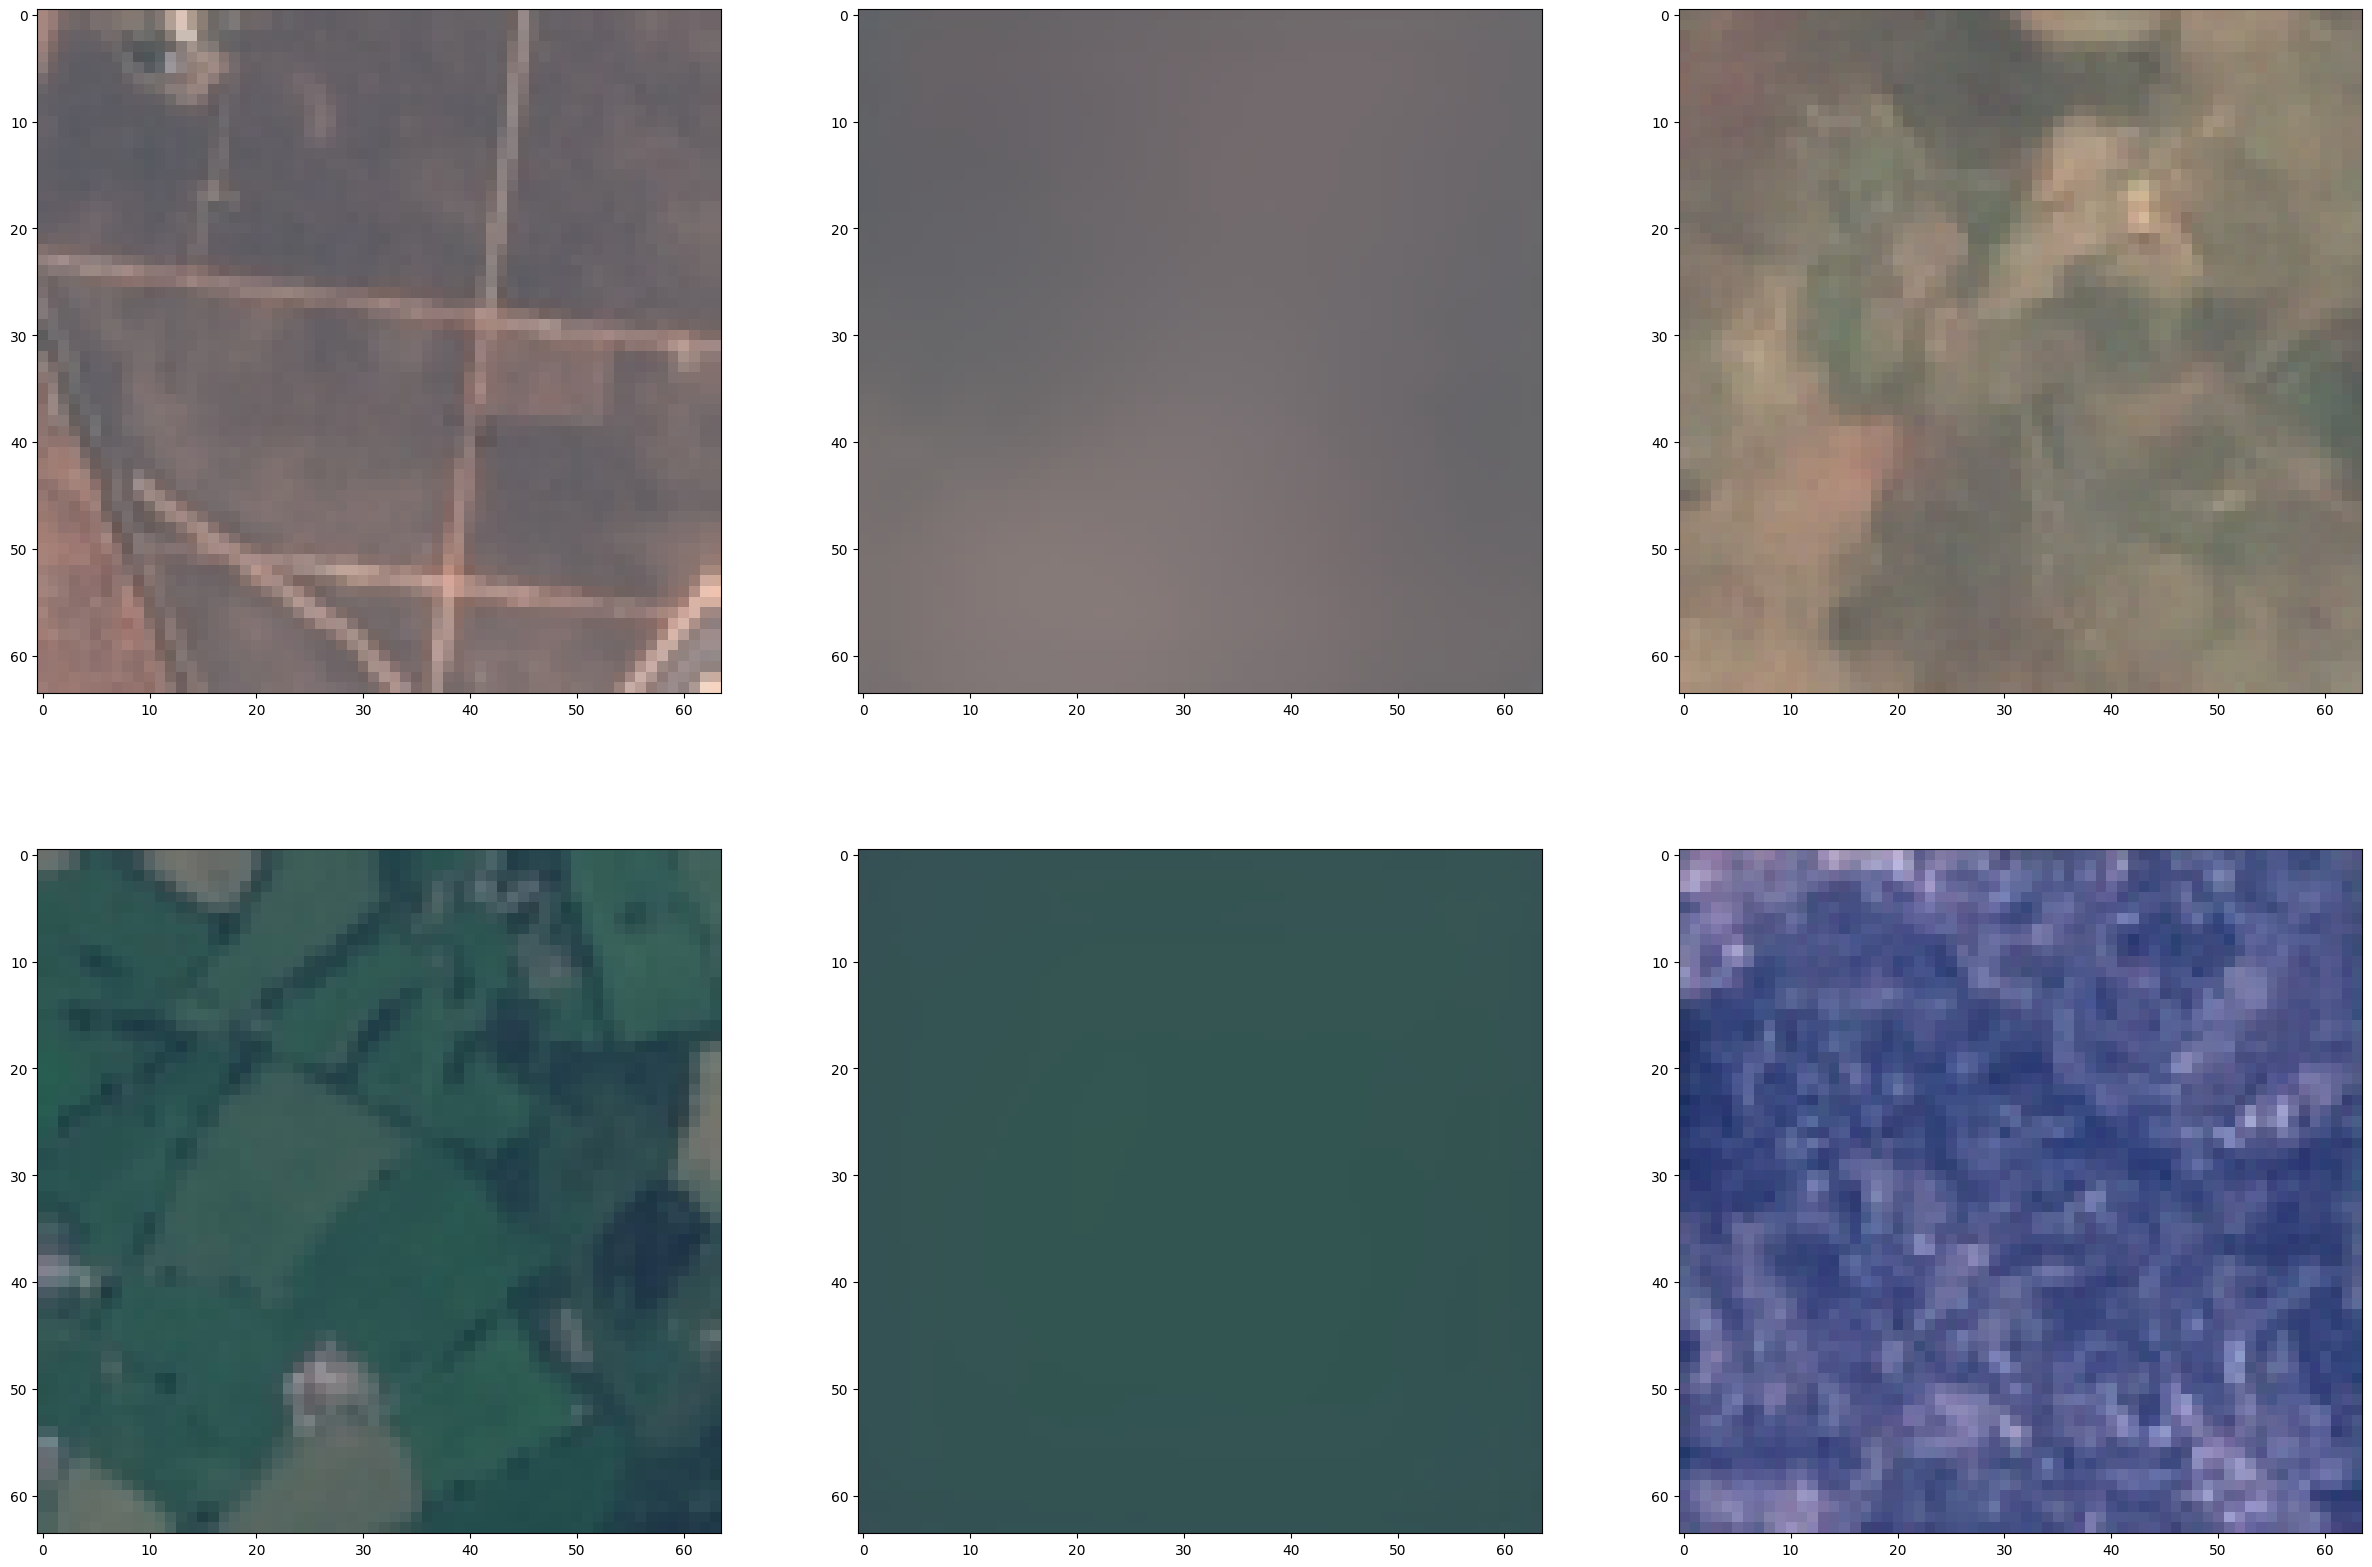

In [90]:
fig, ax = plt.subplots(2, 3, figsize=(30, 20))

ax[0][0].imshow((train_imag.permute(1, 2, 0) + 1) / 2)
ax[0][1].imshow((x_hat_q_train.permute(1, 2, 0) + 1) / 2)
ax[0][2].imshow((refined_train.permute(1, 2, 0) + 1) / 2)

ax[1][0].imshow((val_imag.permute(1, 2, 0) + 1) / 2)
ax[1][1].imshow((x_hat_q_val.permute(1, 2, 0) + 1) / 2)
ax[1][2].imshow((refined_val.permute(1, 2, 0) + 1) / 2)